# LCI Database-Based Normalization Inventory for LCA
## Nils Thonemann & Alexis Laurent

This notebook implements the methodology described in:

> *A Novel Approach to Deriving Globally Consistent Normalization References for LCA Using Unit Process Databases*

It uses the **ecoinvent 3.8 cut-off** database and the **Brightway2.5** framework to:
1. Build a database-wide biosphere inventory weighted by annual production volumes
2. Correct known errors in production volume data
3. Aggregate the inventory into normalization references
4. Compare results against established normalization inventories (DTU/JRC)
5. Calculate characterised normalization references for EF v3.0, ReCiPe, and IMPACTWorld+
6. Propagate uncertainty via Monte Carlo simulation

**Before running:** set the four path variables in the first code cell.


In [1]:
# ============================================================
# USER CONFIGURATION â€” set these paths before running
# ============================================================
from pathlib import Path

ECOINVENT_DIR    = Path(r"path/to/ecoinvent_3.8_cutoff_ecoSpold02/datasets")
LCIA_METHODS_FILE = Path("path/to/Brightway_IW_damage_1_46_and_midpoint_1_28.bw2package")
EI38_DIRECT_CACHE = Path("databases/ei38direct.bw2package")
OUTPUT_DIR        = Path(".")   # directory for all Excel / PNG outputs
# ============================================================

# --- Required libraries ---
import bw2data as bd       # brightway2 project/database management
import bw2calc as bc       # LCA calculation engine
import bw2io as bi         # brightway2 import/export utilities
import time                # for measuring execution time
import pandas as pd        # dataframe manipulation
import matplotlib.pyplot as plt  # plotting
import numpy as np         # numerical operations
from pathlib import Path   # OS-agnostic file path handling
from scipy import stats    # statistical functions (regression, etc.)

# Suppress pandas SettingWithCopyWarning (intentional chained assignment used below)
pd.options.mode.chained_assignment = None


## Checking and Setting the Brightway2.5 Project

In [2]:
# List all brightway2 projects available in this environment
bd.projects


Brightway2 projects manager with 20 objects:
	AB_bete_bw25
	FINAL
	L4M_try4
	Lasers4Maas try_3
	Normalization
	OD_sectors
	Ozone depletion
	Ozone depletion_bw2
	Ozone depletion_bw25
	PlasticPollution
	StableDist
	UncertaintyLCAPhD
	default
	ei371ua
	madeleine test
	materials
	parameters - Excel import
	parameters - manual creation
	premise
	unc
Use `projects.report()` to get a report on all projects.

In [3]:
# Uncomment the lines below to delete and purge the "Normalization" project (destructive â€” use with caution)
#bd.projects.delete_project("Normalization", delete_dir=True)
#bd.projects.purge_deleted_directories()


In [4]:
# Set "Normalization" as the active brightway2 project
bd.projects.set_current("Normalization")


In [5]:
# List all databases registered in the current project
bd.databases


Databases dictionary with 4 object(s):
	Normalization
	biosphere3
	ecoinvent 3.8 cutoff
	ecoinvent 3.8 cutoff direct

In [6]:
# Initialise the brightway2 biosphere3 database and LCIA methods (run once per project)
bi.bw2setup()


Biosphere database already present!!! No setup is needed


In [7]:
# Import ecoinvent 3.8 cut-off only if not already present in the project
# Set ECOINVENT_DIR in the configuration cell at the top of this notebook.
if 'ecoinvent 3.8 cutoff' in bd.databases:
    print("Database has already been imported")
else:
    ei = bi.SingleOutputEcospold2Importer(str(ECOINVENT_DIR), "ecoinvent 3.8 cutoff")
    ei.apply_strategies()
    ei.all_linked
    ei.write_database()


Database has already been imported


In [8]:
# Assign the ecoinvent 3.8 cut-off and biosphere3 databases to shorthand variables
ei38cut = bd.Database("ecoinvent 3.8 cutoff")
#ei38direct = bd.Database("ecoinvent 3.8 cutoff direct")  # alternative direct-linked version (used later)
bio = bd.Database("biosphere3")


In [9]:
# Spot-check: print a random activity and its production exchange properties
for exc in ei38cut.random().production():
    print(exc)
    print(exc['properties'])


Exchange: 1.0 kilowatt hour 'electricity production, wind, 1-3MW turbine, onshore' (kilowatt hour, CN-SD, None) to 'electricity production, wind, 1-3MW turbine, onshore' (kilowatt hour, CN-SD, None)>
{'price': {'amount': 0.0977, 'comment': 'Temporary price data. Calculated as 90% of purchasers price based on: 94% of the average price (to account for a 6% loss in transformation and transmission) for electricity for industrial consumersin 2005 (excluded taxes). From IEA.', 'unit': 'EUR2005'}}


## Correcting Production Volumes

### Nitric acid

The production volume for nitric acid in ecoinvent 3.8 is reported at ~26,882 Mt, which far exceeds the ~57 Mt reported in recent industry sources ([ChemAnalyst 2023](https://www.chemanalyst.com/industry-report/nitric-acid-market-615)). Production volumes are therefore corrected by scaling each regional dataset to its ecoinvent-derived weight fraction of the corrected global total.

Regional weight fractions (from ecoinvent 3.8):

| Region | Weight |
|--------|--------|
| RER w/o RU | 0.3055 |
| RNA | 0.2649 |
| CN | 0.143 |
| RLA | 0.08678 |
| SAS | 0.04158 |
| RU | 0.0377 |
| RAF | 0.03489 |
| UN-SEASIA | 0.03477 |
| RoW | 0.02732 |
| UN-OCEANIA | 0.02348 |

> **Note:** The original notebook listed "FSU" and "RME" as location codes, which do not correspond to ecoinvent 3.8 geography codes. These have been corrected to "RU" and "RoW" respectively, consistent with the code cell below.


In [10]:
# --- Production volume correction: nitric acid ---
# Ecoinvent 3.8 reports nitric acid production at ~26,882 Mt, far exceeding
# the ~57 Mt reported in industry sources (ChemAnalyst 2023).
# Production volumes are redistributed across regions using ecoinvent's
# existing regional weight fractions, then scaled to the corrected global total.

# Regional weight fractions from ecoinvent 3.8 (sum to ~1.0)
NITRIC_ACID_WEIGHTS = {
    "RER w/o RU": 0.3055,
    "RNA":        0.2649,
    "CN":         0.143,
    "RLA":        0.08678,
    "SAS":        0.04158,
    "RU":         0.0377,
    "RAF":        0.03489,
    "UN-SEASIA":  0.03477,
    "RoW":        0.02732,
    "UN-OCEANIA": 0.02348,
}

# Corrected global production volume: 57 Mt/year converted to kg/year
NA_PV_KG = 57 * 1e6 * 1e3

# Absolute regional production volumes (kg/year)
weight_dict = {region: frac * NA_PV_KG for region, frac in NITRIC_ACID_WEIGHTS.items()}

# Update production volumes in the database.
# Allocation keys reflect the co-production split of the 50% solution dataset:
#   1 kg nitric acid  â†’ allocation key = 1 / 1.649
#   0.649 kg steam    â†’ allocation key = 0.649 / 1.649
for act in ei38cut:
    if act['name'] == 'nitric acid production, product in 50% solution state':
        for exc in act.production():
            if act['reference product'] == 'nitric acid, without water, in 50% solution state':
                exc['production volume'] = weight_dict[act['location']] * (1 / 1.649)
            else:
                exc['production volume'] = weight_dict[act['location']] * (0.649 / 1.649)
            exc.save()


### Additional production volume corrections

The following datasets require manual correction of their production volumes:

- **`heat production, at hard coal industrial furnace 1-10MW`**
  Updated to **1.24 Ã— 10Â¹Â² MJ/year** to align with the value reported in newer ecoinvent versions.

- **`treatment of used refrigerant R-12, venting`**
  Updated from the ecoinvent default (4.80 Ã— 10â¸ kg) to **18,300,000 kg/year** based on [Lickley et al. (2021)](https://www.nature.com/articles/s41467-021-23229-2), which reports global CFC-12 banks of 18.3 Gg.


In [11]:
# --- Production volume corrections: hard coal heat and R-12 refrigerant ---
# 1. Hard coal industrial furnace heat: ecoinvent value updated to 1.24e+12 MJ
#    to align with the value in the newer ecoinvent version.
# 2. R-12 refrigerant venting: ecoinvent default (4.80e+8 kg) replaced with
#    18,300,000 kg based on Lickey et al. (2021, Nature Communications),
#    which reports global CFC-12 banks of 18.3 Gg.
#
# Both corrections are applied in a single pass over the database for efficiency.
PV_CORRECTIONS = {
    'heat production, at hard coal industrial furnace 1-10MW': 1.24e+12,
    'treatment of used refrigerant R-12, venting': 18_300_000,
}

for act in ei38cut:
    if act['name'] in PV_CORRECTIONS:
        for exc in act.production():
            exc['production volume'] = PV_CORRECTIONS[act['name']]
            exc.save()


In [12]:
# Verify the updated production volume for hard coal heat (should print 1.24e+12)
for act in ei38cut:
    if act['name'] == 'heat production, at hard coal industrial furnace 1-10MW':
        for exc in act.production():
            print(exc['production volume'])


1240000000000.0
1240000000000.0
1240000000000.0


# Building the Database-Wide Inventory for All Elementary Flows

The core inventory loop iterates over all ~20,000 activities and their exchanges in ecoinvent 3.8 cut-off, collecting biosphere flows weighted by annual production volumes (Equation 3 in the manuscript).

Key observations:
- **Runtime:** approximately 3 minutes on a modern laptop. Results are cached to `ei_complete.pkl`.
- **Reference product amount:** usually 1.0, but treatment datasets use âˆ’1.0 (waste inputs). These datasets mostly lack a registered production volume and are handled separately.
- **Dummy production volumes:** values of 0, 1, or 4 are ecoinvent artefacts from datasets converted from version 2.2 without real production volume data. These are excluded in the cleaning step below.


In [13]:
# --- Build the database-wide biosphere inventory ---
# This cell iterates over all activities and exchanges in ecoinvent 3.8 cut-off
# to collect biosphere flows weighted by annual production volumes.
#
# Key notes:
#   - Runtime: ~3 minutes on a modern laptop.
#   - Reference product amounts are usually 1.0, but treatment datasets use -1.0
#     (waste inputs); those lacking a production volume are handled separately.
#   - Production volumes of 0, 1, or 4 are treated as dummy/missing values
#     (ecoinvent artefact) and filtered out later.
#   - Results are cached to "ei_complete.pkl" to avoid re-running the loop.

ei_complete = Path("ei_complete.pkl")

if ei_complete.exists():
    df = pd.read_pickle(ei_complete)
else:
    start = time.time()

    rows = []  # collect one dict per biosphere exchange

    for activity in ei38cut:
        act = bd.get_activity(activity)
        # Safe defaults in case production exchange is encountered after biosphere ones
        prod_vol      = 0
        refprod_amount = 1
        for exchange in act.exchanges():
            if exchange['type'] == 'production':
                prod_vol       = exchange['production volume']
                refprod_amount = exchange['amount']
            elif exchange['type'] == 'biosphere':
                cats = exchange.input['categories']
                rows.append({
                    'Database':                  act['database'],
                    'Id':                        act['code'],
                    'Name':                      act['name'],
                    'Reference product':         act['reference product'],
                    'Reference product amount':  refprod_amount,
                    'Location':                  act['location'],
                    'ISIC':                      act['ISIC rev.4 ecoinvent'],
                    'CAS number':                exchange.input['CAS number'],
                    'Substance name':            exchange['name'],
                    'Flow_id':                   exchange['flow'],
                    'Type':                      exchange.input['type'],
                    'Compartment':               cats[0],
                    'Subcompartment':            cats[1] if len(cats) > 1 else 'unspecified',
                    'Unit':                      exchange.input['unit'],
                    'Amount':                    exchange['amount'],
                    'Production volume':         prod_vol,
                })

    end = time.time()
    print('Execution time: ' + time.strftime("%H:%M:%S", time.gmtime(end - start)))

    df = pd.DataFrame(rows)
    df.to_pickle('ei_complete.pkl')

df.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
0,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007727-37-9,Nitrogen,e5ea66ee-28e2-4e9b-9a25-4414551d821c,emission,air,unspecified,kilogram,0.017602,3.925170e+08
1,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,"Water, cooling, unspecified natural origin",fc1c42ce-a759-49fa-b987-f1ec5e503db1,natural resource,natural resource,in water,cubic meter,0.015193,3.925170e+08
2,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,Water,2404b41a-2eed-4e9d-8ab6-783946fdf5d6,emission,water,unspecified,cubic meter,0.015471,3.925170e+08
3,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,"Water, well, in ground",67c40aae-d403-464d-9649-c12695e43ad8,natural resource,natural resource,in water,cubic meter,0.000769,3.925170e+08
4,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,0.001297,3.925170e+08


## Analysis of Environmental Flow Coverage

The cells below explore the distribution of environmental flows by type, compartment, and sub-compartment, and generate Figure 1 (sunburst diagram) of the manuscript.

In [14]:
# Count unique environmental flow IDs in the inventory
df['Flow_id'].nunique()


2171

In [15]:
df['Type'].unique().tolist()

['emission', 'natural resource']

In [16]:
df['Compartment'].unique().tolist()

['air', 'natural resource', 'water', 'soil']

In [17]:
df['Subcompartment'].unique().tolist()

['unspecified',
 'in water',
 'land',
 'non-urban air or from high stacks',
 'in ground',
 'surface water',
 'ocean',
 'in air',
 'urban air close to ground',
 'ground-, long-term',
 'agricultural',
 'ground-',
 'biotic',
 'low population density, long-term',
 'lower stratosphere + upper troposphere',
 'industrial',
 'forestry']

In [18]:
df['Type'].value_counts()

Type
emission            353807
natural resource     34645
Name: count, dtype: int64

In [19]:
df['Compartment'].value_counts()

Compartment
air                 192802
water               130851
natural resource     34645
soil                 30154
Name: count, dtype: int64

In [20]:
df['Subcompartment'].value_counts()

Subcompartment
urban air close to ground                 76622
non-urban air or from high stacks         70086
unspecified                               62308
surface water                             62007
ground-, long-term                        27901
agricultural                              22741
ground-                                   15075
land                                      14457
in ground                                  9154
in water                                   6886
ocean                                      6733
low population density, long-term          5055
industrial                                 3834
in air                                     2669
biotic                                     1479
lower stratosphere + upper troposphere      987
forestry                                    458
Name: count, dtype: int64

In [21]:
df.groupby(['Type', 'Compartment', 'Subcompartment']).size().reset_index(name='Count')

,Type,Compartment,Subcompartment,Count
0,emission,air,"low population density, long-term",5055
1,emission,air,lower stratosphere + upper troposphere,987
2,emission,air,non-urban air or from high stacks,70086
3,emission,air,unspecified,40052
4,emission,air,urban air close to ground,76622
5,emission,soil,agricultural,22741
6,emission,soil,forestry,458
7,emission,soil,industrial,3834
8,emission,soil,unspecified,3121
9,emission,water,ground-,15075


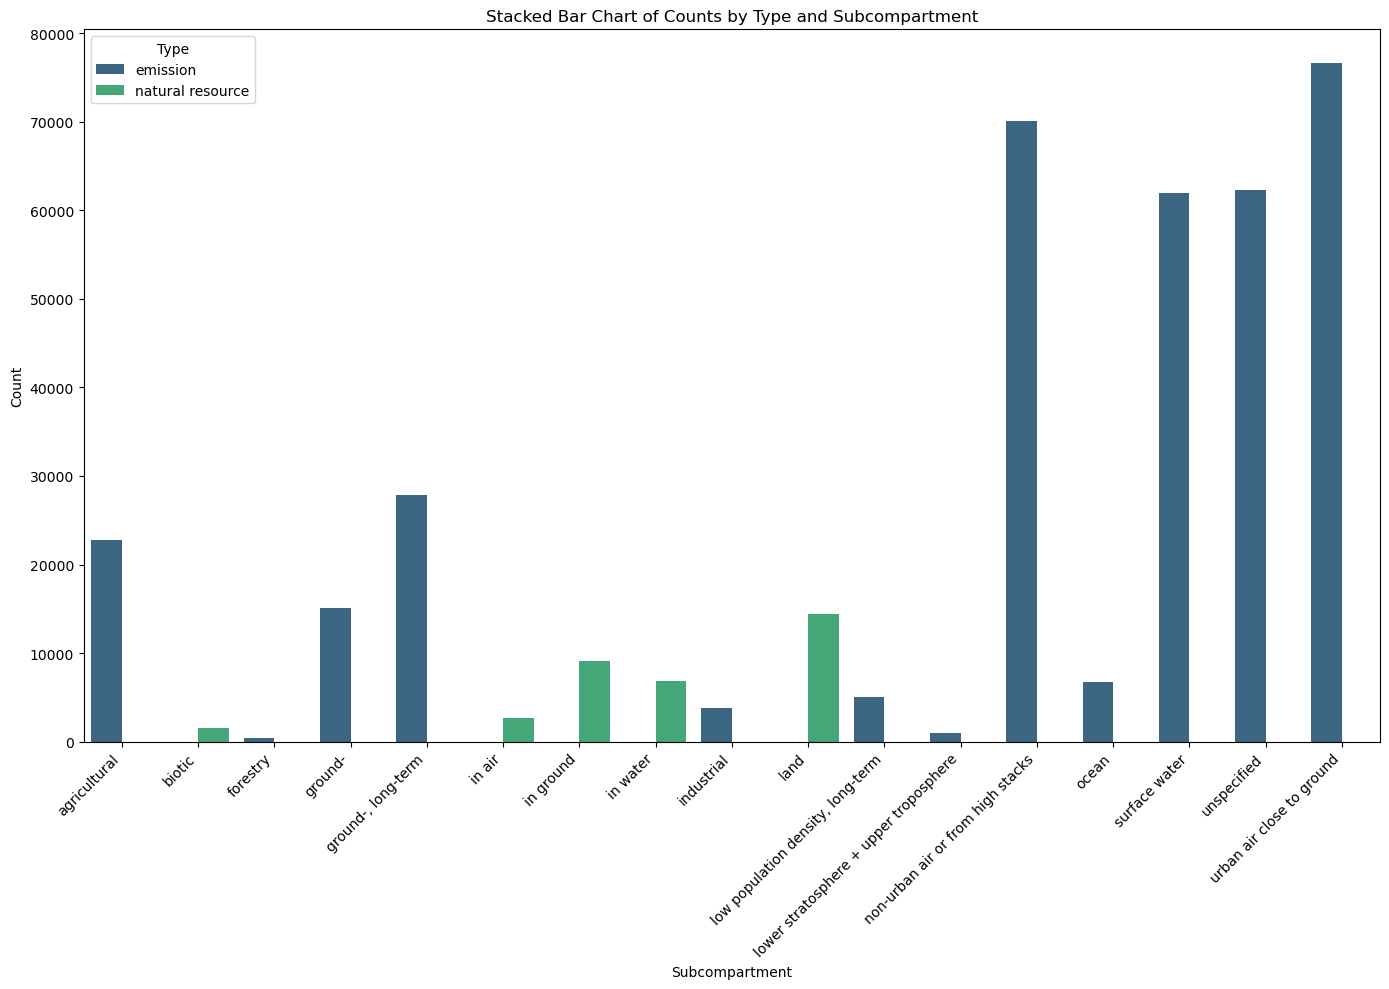

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    'Type': ['emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'natural resource', 'natural resource', 'natural resource', 'natural resource', 'natural resource'],
    'Compartment': ['air', 'air', 'air', 'air', 'air', 'soil', 'soil', 'soil', 'soil', 'water', 'water', 'water', 'water', 'water', 'natural resource', 'natural resource', 'natural resource', 'natural resource', 'natural resource'],
    'Subcompartment': ['low population density, long-term', 'lower stratosphere + upper troposphere', 'non-urban air or from high stacks', 'unspecified', 'urban air close to ground', 'agricultural', 'forestry', 'industrial', 'unspecified', 'ground-', 'ground-, long-term', 'ocean', 'surface water', 'unspecified', 'biotic', 'in air', 'in ground', 'in water', 'land'],
    'Count': [5055, 987, 70086, 40052, 76622, 22741, 458, 3834, 3121, 15075, 27901, 6733, 62007, 19135, 1479, 2669, 9154, 6886, 14457]
}

df_data = pd.DataFrame(data)

# Aggregate the counts to handle duplicates
df_agg = df_data.groupby(['Subcompartment', 'Type'], as_index=False).sum()

# Pivot data for stacked bar chart
stacked_data = df_agg.pivot(index="Subcompartment", columns="Type", values="Count").reset_index()

# Melt the data for plotting
melted_data = pd.melt(stacked_data, id_vars='Subcompartment', var_name='Type', value_name='Count')

# Plot stacked bar chart
plt.figure(figsize=(14, 10))
sns.barplot(data=melted_data, x='Subcompartment', y='Count', hue='Type', palette='viridis')
plt.title('Stacked Bar Chart of Counts by Type and Subcompartment')
plt.xlabel('Subcompartment')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import plotly.express as px
import matplotlib.colors as mcolors

# Data
data = {
    'Type': ['emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'emission', 'natural resource', 'natural resource', 'natural resource', 'natural resource', 'natural resource'],
    'Compartment': ['air', 'air', 'air', 'air', 'air', 'soil', 'soil', 'soil', 'soil', 'water', 'water', 'water', 'water', 'water', 'natural resource', 'natural resource', 'natural resource', 'natural resource', 'natural resource'],
    'Subcompartment': ['low population density, long-term', 'lower stratosphere + upper troposphere', 'non-urban air or from high stacks', 'unspecified', 'urban air close to ground', 'agricultural', 'forestry', 'industrial', 'unspecified', 'ground-', 'ground-, long-term', 'ocean', 'surface water', 'unspecified', 'biotic', 'in air', 'in ground', 'in water', 'land'],
    'Count': [5055, 987, 70086, 40052, 76622, 22741, 458, 3834, 3121, 15075, 27901, 6733, 62007, 19135, 1479, 2669, 9154, 6886, 14457]
}

df_data = pd.DataFrame(data)

# Aggregate the counts to handle duplicates
df_agg = df_data.groupby(['Compartment', 'Subcompartment', 'Type'], as_index=False).sum()

# Define the ggplot color palette
ggplot_palette = plt.get_cmap('tab10').colors
ggplot_palette_hex = [mcolors.rgb2hex(rgb) for rgb in ggplot_palette]

# update layout
fig = px.sunburst(df_agg, path=['Type', 'Compartment', 'Subcompartment'], values='Count', color='Compartment', color_discrete_sequence=ggplot_palette_hex)
fig.update_layout(
    width=800,  # Adjust the width of the plot
    height=600,  # Adjust the height of the plot
    font=dict(
        family="Arial",  # Choose a suitable font family
        size=12,  # Adjust the font size
    ),
)

# Export the figure with at least 300 dpi
#fig.write_image("sunburst_diagram.png", scale=3, engine='kaleido')  # Scale up to achieve at least 300 dpi

fig.show()

# Identifying Exchanges with Negative Amounts

Negative exchange amounts occur in ecoinvent for several reasons:
- **COâ‚‚ uptake** in biomass-producing activities (e.g. crop cultivation)
- **Metal uptake** from soil in agricultural activities
- **Phosphorus uptake** in plant production

These must be identified and handled before computing the normalization inventory, as they can reduce characterised impact scores in certain categories.


In [24]:
# Identify all exchanges with a negative emission/extraction amount
# Negative amounts occur for e.g. CO2 uptake in biomass or metal uptake in crops
df_negative = df[df['Amount'] < 0]
df_negative.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
281,ecoinvent 3.8 cutoff,ff82fb62b8ea7a76dd160a7f22f3952e,"coffee green bean production, arabica","coffee, green bean",1.0,HN,0127:Growing of beverage crops,007440-50-8,Copper,7e66a41c-d311-4949-bdd8-eef09cdcfa47,emission,soil,agricultural,kilogram,-9.050539e-06,2.758432e+08
438,ecoinvent 3.8 cutoff,c9c21a7c851f31e90843004d70284c70,"orange production, processing grade","orange, processing grade",1.0,US,0123:Growing of citrus fruits,007439-97-6,Mercury,ed2d49f8-110d-4db4-9488-f61c349e6117,emission,soil,agricultural,kilogram,-1.769714e-09,6.679750e+09
441,ecoinvent 3.8 cutoff,c9c21a7c851f31e90843004d70284c70,"orange production, processing grade","orange, processing grade",1.0,US,0123:Growing of citrus fruits,007440-66-6,Zinc,84aa799e-9d98-4d34-85e0-516d28ab1be9,emission,soil,agricultural,kilogram,-2.419614e-06,6.679750e+09
1505,ecoinvent 3.8 cutoff,d252de3aa6813e72641d3836f15d8285,"straw production, stand-alone production","straw, stand-alone production",1.0,RoW,"0111:Growing of cereals (except rice), legumin...",007440-47-3,Chromium,e7881581-21b3-4f5c-bd63-6b0684b5e712,emission,soil,agricultural,kilogram,-1.090000e-06,3.966332e+00
1507,ecoinvent 3.8 cutoff,d252de3aa6813e72641d3836f15d8285,"straw production, stand-alone production","straw, stand-alone production",1.0,RoW,"0111:Growing of cereals (except rice), legumin...",007440-66-6,Zinc,84aa799e-9d98-4d34-85e0-516d28ab1be9,emission,soil,agricultural,kilogram,-4.000000e-05,3.966332e+00


In [25]:
# Export the full list of negative-amount flows for manual inspection
df_negative.to_excel('exchanges_w_negative_amount.xlsx')


In [26]:
# UUIDs of metal flows in ecoinvent 3.8 that exhibit plant-uptake behaviour
# (negative amounts in agricultural/forestry activities).
# Defined once here and reused in cells below.
METAL_UPTAKE_FLOW_IDS = frozenset([
    "e429b852-e421-4fcb-8a9b-b0241863bfb2",
    "e7881581-21b3-4f5c-bd63-6b0684b5e712",
    "7e66a41c-d311-4949-bdd8-eef09cdcfa47",
    "237ca6bc-2f0a-4416-a0e3-bd512f038f2e",
    "4010918f-7fd0-4925-8fbb-8fd7a44a806c",
    "ed2d49f8-110d-4db4-9488-f61c349e6117",
    "b4580545-243d-48d2-a3a0-2633a4f46fb1",
    "84aa799e-9d98-4d34-85e0-516d28ab1be9",
    "8d226423-1351-4366-b09f-d16c9e38683c",
    "af83b42f-a4e6-4457-be74-46a87798f82a",
    "e34d3da4-a3d5-41be-84b5-458afe32c990",
    "6d9550e2-e670-44c1-bad8-c0c4975ffca7",
    "b3ebdcc3-c588-4997-95d2-9785b26b34e1",
    "66bfb434-78ab-4183-b1a7-7f87d08974fa",
    "9798359e-a3ee-4362-a038-23a188582c6e",
    "541b633c-17a3-4047-bce6-0c0e4fdb7c10",
    "2c7be02c-791f-4fef-b231-b90321bbeb30",
    "78eb1859-abd9-44c6-9ce3-f3b5b33d619c",
])

# Export negative-amount rows for the metal flow UUIDs to verify they originate
# from plant uptake in agricultural/forestry activities (ISIC 01-02).
df_negative_metals = df_negative[df_negative['Flow_id'].isin(METAL_UPTAKE_FLOW_IDS)]
df_negative_metals.to_excel("metal_flows_neg.xlsx", index=False)


## Analysis of Negative Flows

Breakdown of negative-amount flows by type, compartment, sub-compartment, and substance to guide targeted correction decisions.

In [27]:
# Summary of negative-amount flows by attribute
# (Name, reference product, and ISIC breakdowns are commented out for brevity;
#  uncomment to explore further)
#display(df_negative['Name'].value_counts())
#display(df_negative['Reference product'].value_counts())
#display(df_negative['ISIC'].value_counts())
display("Type",          df_negative['Type'].value_counts())
display("Compartment",   df_negative['Compartment'].value_counts())
display("Subcompartment",df_negative['Subcompartment'].value_counts())
display("Substance name",df_negative['Substance name'].value_counts())


'Type'

Type
emission            1346
natural resource     146
Name: count, dtype: int64

'Compartment'

Compartment
soil                1280
natural resource     146
water                 56
air                   10
Name: count, dtype: int64

'Subcompartment'

Subcompartment
agricultural                 1159
in air                        142
forestry                      120
surface water                  50
unspecified                    13
urban air close to ground       4
biotic                          2
in ground                       2
Name: count, dtype: int64

'Substance name'

Substance name
Copper                                             322
Zinc                                               267
Chromium                                           184
Nickel                                             159
Mercury                                            149
Carbon dioxide, non-fossil, resource correction    137
Lead                                               124
Cadmium                                             82
Zinc, ion                                           19
Copper, ion                                         17
Carbon dioxide, fossil                               8
Nickel, ion                                          6
Carbon dioxide, in air                               5
Chromium, ion                                        3
Methane, fossil                                      2
Energy, gross calorific value, in biomass            2
Cadmium, ion                                         2
Phosphorus                                        

## Treatment of Metal Flows from Plant Uptake

Negative metal flow amounts in ISIC divisions 01 (crop and animal production) and 02 (forestry) represent plant uptake of metals from soil. This is not an emission to the environment and should not contribute to the normalization inventory, particularly for toxicity impact categories. The affected flow UUIDs (`METAL_UPTAKE_FLOW_IDS`) are set to zero for those activities.


In [28]:
# --- Zero out negative metal flows from agricultural plant uptake ---
# For the metal flow UUIDs in METAL_UPTAKE_FLOW_IDS, negative amounts in ISIC
# sectors 01 (crop/animal production) and 02 (forestry) represent plant uptake
# of metals from soil â€” not relevant to the normalization inventory.
# Setting these to zero prevents spurious negative contributions to toxicity categories.
df.loc[
    df['Flow_id'].isin(METAL_UPTAKE_FLOW_IDS) &
    df['ISIC'].str.startswith(('01', '02')) &
    (df['Amount'] < 0),
    'Amount'
] = 0

df.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
0,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007727-37-9,Nitrogen,e5ea66ee-28e2-4e9b-9a25-4414551d821c,emission,air,unspecified,kilogram,0.017602,3.925170e+08
1,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,"Water, cooling, unspecified natural origin",fc1c42ce-a759-49fa-b987-f1ec5e503db1,natural resource,natural resource,in water,cubic meter,0.015193,3.925170e+08
2,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,Water,2404b41a-2eed-4e9d-8ab6-783946fdf5d6,emission,water,unspecified,cubic meter,0.015471,3.925170e+08
3,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,"Water, well, in ground",67c40aae-d403-464d-9649-c12695e43ad8,natural resource,natural resource,in water,cubic meter,0.000769,3.925170e+08
4,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,007732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,0.001297,3.925170e+08


In [29]:
# Verify the correction: re-check the metal flow UUIDs after zeroing out.
# The exported file should show no negative amounts in ISIC 01-02 activities.
df_negative_metals_test = df[df['Flow_id'].isin(METAL_UPTAKE_FLOW_IDS)]
df_negative_metals_test.to_excel("metal_flows_neg_test.xlsx", index=False)


In [30]:
# Confirm that the number of remaining negative-amount rows is now lower.
# Export the residual list for transparency and further review.
df_negative_test = df[df['Amount'] < 0]
df_negative_test.head()

df_negative_test.to_excel('exchanges_w_negative_amount_after_clean.xlsx')


## Treatment of Activities with Dummy Production Volumes

Production volumes of **0**, **1**, or **4** are known ecoinvent artefacts â€” placeholder values used when real production volume data were unavailable at the time of database release (primarily datasets converted from ecoinvent v2.2). These activities are identified here and excluded from the normalization inventory in the cleaning step below.


In [31]:
# Identify activities with dummy production volumes (0, 1, or 4).
# In ecoinvent 3.8, values of 1 or 4 are known placeholder artefacts
# for datasets converted from ecoinvent v2.2 where real data were unavailable.
# These are grouped by activity ID and the first row is kept as representative.
df_prod_vol_err = df[
    (df['Production volume'] == 0) |
    (df['Production volume'] == 1) |
    (df['Production volume'] == 4)
].groupby('Id').first()
print('Number of activities with dummy production volumes: ' + str(len(df_prod_vol_err)))
df_prod_vol_err.head()


Number of activities with erroneous production volumes: 812


,Database,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
Id,,,,,,,,,,,,,,,
001917a47c96c1f5bff351a354a19385,ecoinvent 3.8 cutoff,"treatment of blast furnace gas, in power plant","heat, district or industrial, other than natur...",1.0,CA-NB,"3510:Electric power generation, transmission a...",000630-08-0,"Carbon monoxide, fossil",099b36ab-4c03-4587-87f4-2f81e337afb8,emission,air,non-urban air or from high stacks,kilogram,7.473445e-06,0.0
003ba30e1374a6ea2cfed3594df32399,ecoinvent 3.8 cutoff,"cable production, unspecified","cable, unspecified",1.0,GLO,2732:Manufacture of other electronic and elect...,007732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,8.857200e-05,4.0
00d82cc29d284788b25bb062c9ea13d9,ecoinvent 3.8 cutoff,"treatment of coal gas, in power plant","electricity, high voltage",1.0,CA-NS,"3510:Electric power generation, transmission a...",000071-43-2,Benzene,5e883a00-04e6-4d96-8dce-12d7117c6635,emission,air,non-urban air or from high stacks,kilogram,1.014149e-08,0.0
012a593ef3662beb53ad88178926e496,ecoinvent 3.8 cutoff,"machine operation, diesel, < 18.64 kW, undergr...","machine operation, diesel, < 18.64 kW, undergr...",1.0,GLO,4312:Site preparation,000050-00-0,Formaldehyde,a861cfae-a310-4e9d-b9eb-5d555c9a684c,emission,air,unspecified,kilogram,5.946645e-04,4.0
015954052ced6c82b91c63868d2847e9,ecoinvent 3.8 cutoff,"machine operation, diesel, >= 74.57 kW, low lo...","machine operation, diesel, >= 74.57 kW, low lo...",1.0,GLO,4312:Site preparation,000110-54-3,Hexane,6b248529-b754-4be7-8b1a-91b9756fc2bc,emission,air,unspecified,kilogram,1.352178e-05,4.0


In [32]:
# --- Abandoned approach: recursive production-volume estimation ---
# A recursive traversal through consumer activities was explored to replace
# dummy production volumes (0, 1, 4) with demand-derived estimates.
# This approach was abandoned because it systematically over-estimates emissions
# by accumulating production volumes across the supply chain.
# The cell is preserved for transparency; it is not executed.

# db_lst = df_prod_vol_err['Database'].tolist()
# id_lst = df_prod_vol_err.index.tolist()
# act_lst = list(zip(db_lst, id_lst))
# prod_vol_lst = []
# for act in act_lst:
#     activity = bd.get_activity(act)
#     prod_vol_exc_lst = []
#     for consumer in activity.consumers():
#         potent_market = ei38cut.get(consumer['output'][1])
#         if potent_market['name'].startswith('market for'):
#             for market_consumer in potent_market.consumers():
#                 prod_vol_exc_lst.append(abs(market_consumer['amount'] * market_consumer['production volume']))
#         else:
#             prod_vol_exc_lst.append(abs(consumer['amount'] * consumer['production volume']))
#     prod_vol_lst.append(sum(prod_vol_exc_lst))
# new_prod_vol_dict = dict(zip(id_lst, prod_vol_lst))
# df['Production volume'] = df['Id'].map(new_prod_vol_dict).fillna(df['Production volume'])


In [33]:
# Re-check dummy production volumes after any corrections applied above.
# The count here should be unchanged since the recursive approach (cell above)
# was not used; this serves as a reference baseline.
df_prod_vol_err_after_clean = df[
    (df['Production volume'] == 0) |
    (df['Production volume'] == 1) |
    (df['Production volume'] == 4)
].groupby('Id').first()
print('Number of activities with dummy production volumes after cleaning: ' + str(len(df_prod_vol_err_after_clean)))
df_prod_vol_err_after_clean.head()


Number of activities with erroneous production volumes: 812


,Database,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
Id,,,,,,,,,,,,,,,
001917a47c96c1f5bff351a354a19385,ecoinvent 3.8 cutoff,"treatment of blast furnace gas, in power plant","heat, district or industrial, other than natur...",1.0,CA-NB,"3510:Electric power generation, transmission a...",000630-08-0,"Carbon monoxide, fossil",099b36ab-4c03-4587-87f4-2f81e337afb8,emission,air,non-urban air or from high stacks,kilogram,7.473445e-06,0.0
003ba30e1374a6ea2cfed3594df32399,ecoinvent 3.8 cutoff,"cable production, unspecified","cable, unspecified",1.0,GLO,2732:Manufacture of other electronic and elect...,007732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,8.857200e-05,4.0
00d82cc29d284788b25bb062c9ea13d9,ecoinvent 3.8 cutoff,"treatment of coal gas, in power plant","electricity, high voltage",1.0,CA-NS,"3510:Electric power generation, transmission a...",000071-43-2,Benzene,5e883a00-04e6-4d96-8dce-12d7117c6635,emission,air,non-urban air or from high stacks,kilogram,1.014149e-08,0.0
012a593ef3662beb53ad88178926e496,ecoinvent 3.8 cutoff,"machine operation, diesel, < 18.64 kW, undergr...","machine operation, diesel, < 18.64 kW, undergr...",1.0,GLO,4312:Site preparation,000050-00-0,Formaldehyde,a861cfae-a310-4e9d-b9eb-5d555c9a684c,emission,air,unspecified,kilogram,5.946645e-04,4.0
015954052ced6c82b91c63868d2847e9,ecoinvent 3.8 cutoff,"machine operation, diesel, >= 74.57 kW, low lo...","machine operation, diesel, >= 74.57 kW, low lo...",1.0,GLO,4312:Site preparation,000110-54-3,Hexane,6b248529-b754-4be7-8b1a-91b9756fc2bc,emission,air,unspecified,kilogram,1.352178e-05,4.0


## Checking CAS Numbers

Verifies how many unique CAS numbers are present in the inventory and checks for missing values before the final cleaning step.

In [34]:
# Count the number of unique CAS numbers in the assembled inventory DataFrame
print('Total number of unique CAS numbers in dataframe:', df['CAS number'].nunique())


Total numbers of unique CAS numbers in dataframe: 764


## Final Data Cleaning and Normalization Inventory Assembly

This section:
1. Removes activities with dummy production volumes
2. Excludes specific natural gas boiler datasets with unreliable production volumes
3. Standardises CAS numbers
4. Computes total annual flows (`Amount Ã— Production volume`)
5. Aggregates to flow level to produce the normalization inventory (`df_ei_norm`)


In [35]:
# --- Final data cleaning and filtering ---
# 1. Remove rows with dummy production volumes (0, 1, or 4).
# 2. Exclude specific natural gas boiler heat datasets for RoW location only.
#    These are known to have unreliable production volumes in ecoinvent 3.8.
#    NOTE: The location filter applies to ALL boiler names (isin), not just the last.
# 3. Normalise CAS numbers: fill NaN with "NOCAS" and strip leading zeros
#    to ensure consistent matching with external inventories (e.g. DTU).

DUMMY_PV = {0, 1, 4}
df = df.loc[~df['Production volume'].isin(DUMMY_PV), :]

BOILER_NAMES = {
    'heat production, natural gas, at boiler fan burner non-modulating <100kW',
    'heat production, natural gas, at boiler modulating <100kW',
    'heat production, natural gas, at boiler condensing modulating <100kW',
    'heat production, natural gas, at boiler atm. low-NOx condensing non-modulating <100kW',
    'heat production, natural gas, at boiler atmospheric non-modulating <100kW',
    'heat production, natural gas, at boiler atmospheric low-NOx non-modulating <100kW',
    'heat production, natural gas, at boiler fan burner low-NOx non-modulating <100kW',
}
df = df.loc[~(df['Name'].isin(BOILER_NAMES) & (df['Location'] == 'RoW')), :]

# Replace NaN CAS numbers with "NOCAS" placeholder, then strip leading zeros
df['CAS number'] = df['CAS number'].fillna('NOCAS')
df['CAS number'] = np.where(
    df['CAS number'] == 'NOCAS',
    'NOCAS',
    df['CAS number'].str.lstrip('0')
)

df.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
0,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7727-37-9,Nitrogen,e5ea66ee-28e2-4e9b-9a25-4414551d821c,emission,air,unspecified,kilogram,0.017602,3.925170e+08
1,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, cooling, unspecified natural origin",fc1c42ce-a759-49fa-b987-f1ec5e503db1,natural resource,natural resource,in water,cubic meter,0.015193,3.925170e+08
2,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,2404b41a-2eed-4e9d-8ab6-783946fdf5d6,emission,water,unspecified,cubic meter,0.015471,3.925170e+08
3,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, well, in ground",67c40aae-d403-464d-9649-c12695e43ad8,natural resource,natural resource,in water,cubic meter,0.000769,3.925170e+08
4,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,0.001297,3.925170e+08


In [36]:
# Create a version of the DataFrame excluding negative-amount flows entirely
# (used in parallel with the full df to assess the sensitivity of results
# to the inclusion of negative emissions such as CO2 uptake)
df_without_negative = df[df['Amount'] > 0]
df_without_negative.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume
0,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7727-37-9,Nitrogen,e5ea66ee-28e2-4e9b-9a25-4414551d821c,emission,air,unspecified,kilogram,0.017602,3.925170e+08
1,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, cooling, unspecified natural origin",fc1c42ce-a759-49fa-b987-f1ec5e503db1,natural resource,natural resource,in water,cubic meter,0.015193,3.925170e+08
2,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,2404b41a-2eed-4e9d-8ab6-783946fdf5d6,emission,water,unspecified,cubic meter,0.015471,3.925170e+08
3,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, well, in ground",67c40aae-d403-464d-9649-c12695e43ad8,natural resource,natural resource,in water,cubic meter,0.000769,3.925170e+08
4,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,0.001297,3.925170e+08


In [37]:
# Calculate the total emission/extraction amount per exchange per year:
#   Total amount = exchange amount per unit output Ã— annual production volume
# This yields the absolute annual flow (kg/year or equivalent) for each row.
total_amount = df['Amount'] * df['Production volume']
df['Total amount'] = total_amount
df.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume,Total amount
0,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7727-37-9,Nitrogen,e5ea66ee-28e2-4e9b-9a25-4414551d821c,emission,air,unspecified,kilogram,0.017602,3.925170e+08,6.909095e+06
1,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, cooling, unspecified natural origin",fc1c42ce-a759-49fa-b987-f1ec5e503db1,natural resource,natural resource,in water,cubic meter,0.015193,3.925170e+08,5.963640e+06
2,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,2404b41a-2eed-4e9d-8ab6-783946fdf5d6,emission,water,unspecified,cubic meter,0.015471,3.925170e+08,6.072731e+06
3,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, well, in ground",67c40aae-d403-464d-9649-c12695e43ad8,natural resource,natural resource,in water,cubic meter,0.000769,3.925170e+08,3.018184e+05
4,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,0.001297,3.925170e+08,5.090912e+05


In [38]:
# Spot-check: export all NMVOC entries for manual inspection and comparison
# with external statistics (used to verify production volume data quality)
df[df['Substance name'] == 'NMVOC, non-methane volatile organic compounds, unspecified origin'].to_excel('substance_check.xlsx')


In [39]:
# Apply the same total amount calculation to the negative-free DataFrame
total_amount = df_without_negative['Amount'] * df_without_negative['Production volume']
df_without_negative['Total amount'] = total_amount
df_without_negative.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume,Total amount
0,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7727-37-9,Nitrogen,e5ea66ee-28e2-4e9b-9a25-4414551d821c,emission,air,unspecified,kilogram,0.017602,3.925170e+08,6.909095e+06
1,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, cooling, unspecified natural origin",fc1c42ce-a759-49fa-b987-f1ec5e503db1,natural resource,natural resource,in water,cubic meter,0.015193,3.925170e+08,5.963640e+06
2,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,2404b41a-2eed-4e9d-8ab6-783946fdf5d6,emission,water,unspecified,cubic meter,0.015471,3.925170e+08,6.072731e+06
3,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,"Water, well, in ground",67c40aae-d403-464d-9649-c12695e43ad8,natural resource,natural resource,in water,cubic meter,0.000769,3.925170e+08,3.018184e+05
4,ecoinvent 3.8 cutoff,5d077a2fb969d0ff968199686b0c79ae,stearic acid production,stearic acid,1.0,GLO,2011:Manufacture of basic chemicals,7732-18-5,Water,075e433b-4be4-448e-9510-9a5029c1ce94,emission,air,unspecified,cubic meter,0.001297,3.925170e+08,5.090912e+05


In [40]:
# Spot-check CO2 (CAS 124-38-9): extract all CO2 entries sorted by contribution
# to identify the largest emitting activities for plausibility assessment
df_CO2 = df[df['CAS number'] == '124-38-9'].sort_values(by='Total amount', ascending=False)
df_CO2.to_excel('CO2_analysis.xlsx')


In [41]:
# Aggregate CO2 totals by compartment to get a single emission value per receiving medium
df_CO2 = df_CO2.groupby(['CAS number', 'Compartment', 'Unit'], as_index=False).agg(
    {'Substance name': 'first', 'Total amount': 'sum'}
)
df_CO2


,CAS number,Compartment,Unit,Substance name,Total amount
0,124-38-9,air,kilogram,"Carbon dioxide, fossil",4.794883e+13
1,124-38-9,natural resource,kilogram,"Carbon dioxide, in air",1.961096e+13
2,124-38-9,soil,kilogram,"Carbon dioxide, to soil or biomass stock",3.310076e+10


In [42]:
df_ei_ionrad_complete = df[df['Unit'] == 'kilo Becquerel']
df_ei_ionrad_complete = df_ei_ionrad_complete.groupby(['Flow_id', 'CAS number', 'Compartment', 'Subcompartment', 'Unit'], as_index=False).agg({'Substance name': 'first', 'Total amount': 'sum'})
df_ei_ionrad_complete.head()

,Flow_id,CAS number,Compartment,Subcompartment,Unit,Substance name,Total amount
0,001790f3-fd86-4a0d-a2a1-06c7099d90c8,14835-21-3,air,non-urban air or from high stacks,kilo Becquerel,Xenon-137,5.008505e+09
1,0097bf60-3729-40b6-94d0-06bd6146cfc2,10045-97-3,water,ocean,kilo Becquerel,Cesium-137,6.441830e+09
2,00e73fdb-98df-4a03-8290-79931cddfd12,14255-04-0,air,unspecified,kilo Becquerel,Lead-210,1.701611e+07
3,01f511e2-7030-45f0-abb7-c24a4fae698b,14234-35-6,water,surface water,kilo Becquerel,Antimony-125,5.833729e+07
4,02703daf-fde4-489a-b7e5-523e46151312,NOCAS,air,non-urban air or from high stacks,kilo Becquerel,"Actinides, radioactive, unspecified",1.430998e+09


In [43]:
df_ei_ionrad_complete.to_excel('Global_inventory_ionizing_radiation_ecoinvent_3.8_complete.xlsx')

In [44]:
df_ei_ionrad = df[df['Unit'] == 'kilo Becquerel']
df_ei_ionrad = df_ei_ionrad.groupby(['CAS number', 'Compartment', 'Subcompartment', 'Unit'], as_index=False).agg({'Substance name': 'first', 'Total amount': 'sum'})
df_ei_ionrad

,CAS number,Compartment,Subcompartment,Unit,Substance name,Total amount
0,10028-17-8,air,non-urban air or from high stacks,kilo Becquerel,"Hydrogen-3, Tritium",1.904216e+11
1,10028-17-8,water,ocean,kilo Becquerel,"Hydrogen-3, Tritium",1.338380e+13
2,10028-17-8,water,surface water,kilo Becquerel,"Hydrogen-3, Tritium",2.439158e+13
3,10043-66-0,air,non-urban air or from high stacks,kilo Becquerel,Iodine-131,7.705174e+08
4,10043-66-0,water,surface water,kilo Becquerel,Iodine-131,8.136944e+08
...,...,...,...,...,...,...
143,NOCAS,air,non-urban air or from high stacks,kilo Becquerel,"Actinides, radioactive, unspecified",3.327376e+14
144,NOCAS,air,unspecified,kilo Becquerel,"Radioactive species, other beta emitters",2.914433e+00
145,NOCAS,air,urban air close to ground,kilo Becquerel,"Radioactive species, other beta emitters",3.937143e+05
146,NOCAS,water,ocean,kilo Becquerel,"Actinides, radioactive, unspecified",3.366576e+10


In [45]:
df_ei_ionrad.to_excel('Global_inventory_ionizing_radiation_ecoinvent_3.8_new_w_subcompartments.xlsx')

In [46]:
# Aggregate the inventory to flow level:
# group by unique flow ID, CAS number, compartment, sub-compartment and unit,
# and sum the total amounts. This is the core normalization inventory.
df_ei_norm = df.groupby(
    ['Flow_id', 'CAS number', 'Compartment', 'Subcompartment', 'Unit'],
    as_index=False
).agg({'Substance name': 'first', 'Total amount': 'sum'})
df_ei_norm.head()


,Flow_id,CAS number,Compartment,Subcompartment,Unit,Substance name,Total amount
0,00012c0a-9bff-4787-a7eb-56c3d2f43692,51218-45-2,water,ground-,kilogram,Metolachlor,3.638914e+04
1,00143719-33a7-5738-aa1b-131f97b4fef3,7440-21-3,natural resource,in ground,kilogram,"Silicon, in ground",5.033628e+09
2,0015ec22-72cb-4af1-8c7b-0ba0d041553c,145701-23-1,soil,agricultural,kilogram,Florasulam,2.005496e+04
3,0017271e-7df5-40bc-833a-36110c1fe5d5,14797-65-0,water,surface water,kilogram,Nitrite,9.193138e+07
4,001790f3-fd86-4a0d-a2a1-06c7099d90c8,14835-21-3,air,non-urban air or from high stacks,kilo Becquerel,Xenon-137,5.008505e+09


In [47]:
df_ei_norm['Unit'].unique()

array(['kilogram', 'kilo Becquerel', 'square meter', 'megajoule',
       'square meter-year', 'cubic meter', 'cubic meter-year'],
      dtype=object)

In [48]:
# Export a toxicity-relevant subset: non-resource flows in kg only
# (used for the toxicity normalization inventory submitted with the manuscript)
df_complete = df_ei_norm[
    (df_ei_norm['Compartment'] != 'natural resource') &
    (df_ei_norm['Unit'] == 'kilogram')
]
df_complete.to_excel('Normalization_Inventory_Toxics.xlsx')


In [49]:
# Build the same aggregated normalization inventory from the negative-free DataFrame
# for comparison against the full inventory (sensitivity analysis)
df_ei_norm_without_negative = df_without_negative.groupby(
    ['Flow_id', 'CAS number', 'Compartment', 'Subcompartment', 'Unit'],
    as_index=False
).agg({'Substance name': 'first', 'Total amount': 'sum'})
df_ei_norm_without_negative.head()


,Flow_id,CAS number,Compartment,Subcompartment,Unit,Substance name,Total amount
0,00012c0a-9bff-4787-a7eb-56c3d2f43692,51218-45-2,water,ground-,kilogram,Metolachlor,3.638914e+04
1,00143719-33a7-5738-aa1b-131f97b4fef3,7440-21-3,natural resource,in ground,kilogram,"Silicon, in ground",5.033628e+09
2,0015ec22-72cb-4af1-8c7b-0ba0d041553c,145701-23-1,soil,agricultural,kilogram,Florasulam,2.005496e+04
3,0017271e-7df5-40bc-833a-36110c1fe5d5,14797-65-0,water,surface water,kilogram,Nitrite,9.193138e+07
4,001790f3-fd86-4a0d-a2a1-06c7099d90c8,14835-21-3,air,non-urban air or from high stacks,kilo Becquerel,Xenon-137,5.008505e+09


In [50]:
# Export the complete normalization inventory to Excel
df_ei_norm.to_excel('Normalization_complete_new.xlsx')


# Sector Analysis

Contribution analysis of the normalization inventory by ISIC industrial division, using EF v3.0 climate change characterisation factors. This generates Figure 5 of the manuscript (bar chart of global warming impact by sector).


In [51]:
# --- Sector analysis: climate change impact ---
# Load EF v3.0 climate change characterization factors (excluding long-term
# and EN15804 variants) and map them to the inventory DataFrame.
# Then calculate characterised GWI per activity for contribution analysis.
EF = [m for m in bd.methods if 'EF v3.0' in m[0] and 'no LT' not in str(m) and 'EN15804' not in str(m)]
CC = bd.Method(EF[1]).load()

# Extract flow IDs and build a CAS-to-CF lookup dictionary
CC_flow_ids = [CF[0][1] for CF in CC]
CC_dict     = {CF[0][1]: CF[1] for CF in CC}

# Filter inventory to flows with a climate change CF
CC_df = df[df['Flow_id'].isin(CC_flow_ids)]

# Map characterization factors and calculate inventory and impact contributions
CC_df['CC']           = CC_df['Flow_id'].map(CC_dict)
CC_df['CC_inventory'] = CC_df['Amount'] * CC_df['Production volume']
CC_df['CC_impact']    = CC_df['CC_inventory'] * CC_df['CC']
CC_df.head()


,Database,Id,Name,Reference product,Reference product amount,Location,ISIC,CAS number,Substance name,Flow_id,Type,Compartment,Subcompartment,Unit,Amount,Production volume,Total amount,CC,CC_inventory,CC_impact
25,ecoinvent 3.8 cutoff,f59c5e02447c0060fc578f80f4a3c5fb,"C3 hydrocarbon production, mixture, petroleum ...",C3 hydrocarbon mixture,1.0,CO,1920:Manufacture of refined petroleum products,10024-97-2,Dinitrogen monoxide,20185046-64bb-4c09-a8e7-e8a9e144ca98,emission,air,unspecified,kilogram,0.000017,37859699.0,6.453127e+02,298.00,6.453127e+02,1.923032e+05
40,ecoinvent 3.8 cutoff,f59c5e02447c0060fc578f80f4a3c5fb,"C3 hydrocarbon production, mixture, petroleum ...",C3 hydrocarbon mixture,1.0,CO,1920:Manufacture of refined petroleum products,630-08-0,"Carbon monoxide, fossil",ba2f3f82-c93a-47a5-822a-37ec97495275,emission,air,unspecified,kilogram,0.000511,37859699.0,1.933050e+04,1.57,1.933050e+04,3.034889e+04
68,ecoinvent 3.8 cutoff,f59c5e02447c0060fc578f80f4a3c5fb,"C3 hydrocarbon production, mixture, petroleum ...",C3 hydrocarbon mixture,1.0,CO,1920:Manufacture of refined petroleum products,74-82-8,"Methane, fossil",0795345f-c7ae-410c-ad25-1845784c75f5,emission,air,unspecified,kilogram,0.000027,37859699.0,1.037549e+03,36.80,1.037549e+03,3.818180e+04
106,ecoinvent 3.8 cutoff,f59c5e02447c0060fc578f80f4a3c5fb,"C3 hydrocarbon production, mixture, petroleum ...",C3 hydrocarbon mixture,1.0,CO,1920:Manufacture of refined petroleum products,124-38-9,"Carbon dioxide, fossil",349b29d1-3e58-4c66-98b9-9d1a076efd2e,emission,air,unspecified,kilogram,0.471905,37859699.0,1.786617e+07,1.00,1.786617e+07,1.786617e+07
117,ecoinvent 3.8 cutoff,24f0c28751025f590dedc6548733f261,"electricity production, hydro, pumped storage","electricity, high voltage",1.0,CN-HB,"3510:Electric power generation, transmission a...",10024-97-2,Dinitrogen monoxide,afd6d670-bbb0-4625-9730-04088a5b035e,emission,air,non-urban air or from high stacks,kilogram,0.000000,515790000.0,0.000000e+00,298.00,0.000000e+00,0.000000e+00


In [52]:
CC_df['CC_impact'].sum()

54388496272914.91

In [53]:
# Identify activities with a reference product amount of -1 (waste treatment datasets)
# These require special handling as their "production" is waste consumption
# --> to be discussed with co-authors regarding appropriate treatment
CC_df[CC_df['Reference product amount'] == -1]['Name'].value_counts()


Name
clinker production                                                                229
treatment of municipal solid waste, incineration                                  125
treatment of municipal solid waste, sanitary landfill                              27
treatment of waste bitumen, sanitary landfill                                      21
treatment of waste polyurethane, sanitary landfill                                 14
                                                                                 ... 
treatment of used refrigerant R134a, final disposal                                 1
treatment of used refrigerant R134a, reclamation                                    1
treatment of used refrigerant R-12, venting                                         1
treatment of used refrigerant R134a, venting                                        1
treatment of used refrigeration machine, carbon dioxide, liquid as refrigerant      1
Name: count, Length: 213, dtype: int64

In [54]:
strict_grouped_df = CC_df.groupby(['Name', 'Reference product'])['CC_impact'].sum().reset_index().sort_values(by='CC_impact', ascending=False)
strict_grouped_df

,Name,Reference product,CC_impact
603,"heat production, anthracite, at stove 5-15kW","heat, central or small-scale, other than natur...",9.645377e+12
379,"electricity production, hard coal","electricity, high voltage",6.865567e+12
545,hard coal mine operation and hard coal prepara...,hard coal,2.266609e+12
388,"electricity production, lignite","electricity, high voltage",2.037852e+12
246,clinker production,clinker,1.676223e+12
...,...,...,...
729,"land use change, perennial crop","land use change, perennial crop",-1.103716e+09
721,"land already in use, pasture, man made to pere...","land tenure, arable land, measured as carbon n...",-1.981467e+09
715,"land already in use, annual cropland to perenn...","land tenure, arable land, measured as carbon n...",-4.312362e+09
727,"land use change, paddy rice","land use change, paddy rice",-1.963184e+10


In [55]:
grouped_df = CC_df.groupby(['Name', 'Reference product', 'Id', 'Location', 'ISIC'])[['CC_inventory', 'CC_impact']].sum().reset_index().sort_values(by='CC_impact', ascending=False)
grouped_df

,Name,Reference product,Id,Location,ISIC,CC_inventory,CC_impact
2409,"heat production, anthracite, at stove 5-15kW","heat, central or small-scale, other than natur...",1b9d99571d8191e921a7740fab4f65ef,RoW,3530:Steam and air conditioning supply,8.441173e+12,9.537177e+12
1829,hard coal mine operation and hard coal prepara...,hard coal,517326bbcb3a1d2b90807e9e7988918c,CN,0510:Mining of hard coal,8.968944e+10,1.669855e+12
665,clinker production,clinker,58fb1fec1918f18532765c406ebc8c60,RoW,"2394:Manufacture of cement, lime and plaster",1.227519e+12,1.228434e+12
2439,"heat production, heavy fuel oil, at industrial...","heat, district or industrial, other than natur...",6338d648ed10f78481409ed5c3aa2d9a,RoW,3530:Steam and air conditioning supply,1.027760e+12,1.032299e+12
4199,pig iron production,pig iron,7c3fc8eeef928c8667a29c60fa31fd7c,RoW,2410:Manufacture of basic iron and steel,9.351997e+11,9.360399e+11
...,...,...,...,...,...,...,...
6037,urea production,urea,beb37eff92ec125d28432ecf3c9cfd51,RNA,2012:Manufacture of fertilizers and nitrogen c...,-7.204004e+09,-7.204004e+09
6035,urea production,urea,3a785e7a597a0d6588b6a9139b5a421d,RER,2012:Manufacture of fertilizers and nitrogen c...,-8.930575e+09,-8.930575e+09
2876,"land use change, paddy rice","land use change, paddy rice",6f9433a2a0e0982876b3c0d7b3be06aa,IN,0161:Support activities for crop production,1.447092e+10,-1.447092e+10
6034,urea production,urea,0d7a1712279415eb0f071358c64166da,CN,2012:Manufacture of fertilizers and nitrogen c...,-4.864090e+10,-4.864090e+10


In [56]:
isic_df = CC_df.groupby(['ISIC'])[['CC_inventory', 'CC_impact']].sum().reset_index().sort_values(by='CC_impact', ascending=False)
isic_df['ISIC_Division'] = isic_df['ISIC'].str[:2].str.lstrip('0').astype(int)
isic_df

,ISIC,CC_inventory,CC_impact,ISIC_Division
78,"3510:Electric power generation, transmission a...",1.377375e+13,1.404387e+13,35
80,3530:Steam and air conditioning supply,1.270219e+13,1.403349e+13,35
16,0141:Raising of cattle and buffaloes,1.113270e+11,2.846682e+12,1
95,4922:Other passenger land transport,2.588416e+12,2.619753e+12,49
29,0510:Mining of hard coal,2.016850e+11,2.401728e+12,5
...,...,...,...,...
57,2219:Manufacture of other rubber products,9.009680e-01,9.015198e-01,22
99,5022:Inland freight water transport,2.286217e-01,2.359238e-01,50
69,2592:Treatment and coating of metals; machining,1.741456e-01,1.749126e-01,25
35,"0810:Quarrying of stone, sand and clay",1.037835e-01,1.129275e-01,8


In [57]:
df_isic = pd.read_excel("ISIC.xlsx", sheet_name=1)
dict_div = dict(zip(df_isic['division'],df_isic['division_label']))

In [58]:
isic_df['Division'] = isic_df['ISIC_Division'].map(dict_div)
isic_df = isic_df.groupby(['Division'])[['CC_inventory', 'CC_impact']].sum().reset_index().sort_values(by='CC_impact', ascending=False)
isic_df

,Division,CC_inventory,CC_impact
2,"Electricity, gas, steam and air conditioning s...",2.650647e+13,2.842281e+13
1,"Crop and animal production, hunting and relate...",2.034774e+12,7.680126e+12
6,Land transport and transport via pipelines,4.829858e+12,5.131046e+12
21,Mining of coal and lignite,2.019446e+11,2.411281e+12
16,Manufacture of other non-metallic mineral prod...,1.934705e+12,1.936813e+12
7,Manufacture of basic metals,1.709953e+12,1.773466e+12
9,Manufacture of coke and refined petroleum prod...,1.441277e+12,1.646455e+12
27,"Waste collection, treatment and disposal activ...",3.884089e+11,1.594330e+12
29,Water transport,1.085627e+12,1.103180e+12
3,Extraction of crude petroleum and natural gas,4.177973e+10,9.630237e+11


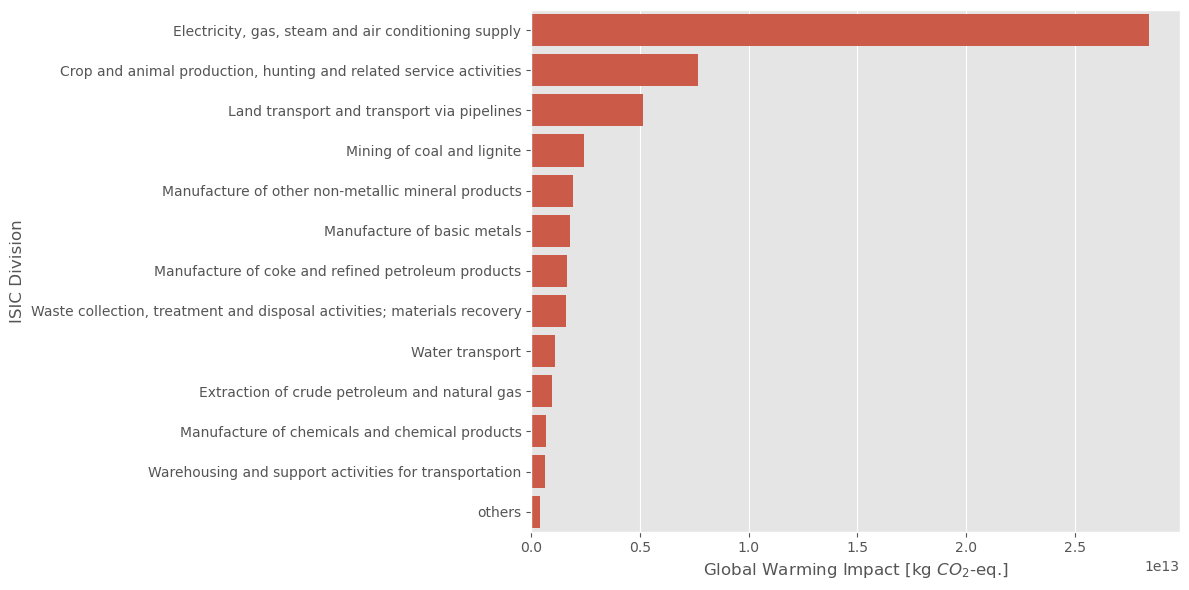

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming grouped_df is your DataFrame with 'ISIC' and 'CC_impact' columns
# Set a threshold for grouping into "others"
threshold = 1.1E11  # Example threshold for CC_impact

# Create a mask for entries below the threshold
mask = isic_df['CC_impact'] < threshold

# Sum the CC_impact values of the entries below the threshold
others_sum = isic_df.loc[mask, 'CC_impact'].sum()

# Create a new DataFrame for entries above the threshold
above_threshold = isic_df.loc[~mask]

# Create a DataFrame for the "others" row
others_row = pd.DataFrame({'Division': ['others'], 'CC_impact': [others_sum]})

# Concatenate the above_threshold DataFrame with the others_row DataFrame
final_df = pd.concat([above_threshold, others_row], ignore_index=True)

# Sort the final DataFrame by CC_impact
final_df = final_df.sort_values(by='CC_impact', ascending=False)

# Set seaborn style
plt.style.use('ggplot')

# Create the bar chart using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='CC_impact', y='Division', data=final_df)
plt.xlabel('Global Warming Impact [kg $CO_2$-eq.]')
plt.ylabel('ISIC Division')
#plt.title('CC_Impact by ISIC Division')
plt.tight_layout()

plt.savefig('CC_impact_sector_bar_chart.png')

# Result Characterisation

This section registers the normalization inventory as a Brightway2 activity and characterises it using three LCIA method families:
- **EF v3.0** (Product Environmental Footprint)
- **ReCiPe Midpoint (H) V1.13**
- **IMPACTWorld+**

Two inventory variants are characterised in parallel:
- `norm` â€” full inventory (including negative flows)
- `norm_without_negative` â€” inventory with all negative flows removed

The ratio between the two (`Comparison` column) quantifies the sensitivity of normalization references to the treatment of negative emissions (discussed in the manuscript).

## LCI â€” Registering the Inventories


In [60]:
del bd.databases['Normalization']
norm = bd.Database('Normalization')
norm.register()

In [61]:
global_inventory = norm.new_activity(code = 'norm', name = 'Global inventory', unit = 'year')
global_inventory.save()

In [62]:
# Populate the "Global inventory" brightway2 activity with all biosphere flows
# from the aggregated normalization inventory.
for flow_id, amount, unit in zip(
    df_ei_norm['Flow_id'],
    df_ei_norm['Total amount'],
    df_ei_norm['Unit'],
):
    global_inventory.new_exchange(
        input=bio.get(flow_id), amount=amount, unit=unit, type='biosphere'
    ).save()
global_inventory.save()


In [63]:
global_inventory_without_negative = norm.new_activity(code = 'norm_without_negative', name = 'Global inventory without negative', unit = 'year')
global_inventory_without_negative.save()

In [64]:
# Populate the negative-free variant of the "Global inventory" activity
for flow_id, amount, unit in zip(
    df_ei_norm_without_negative['Flow_id'],
    df_ei_norm_without_negative['Total amount'],
    df_ei_norm_without_negative['Unit'],
):
    global_inventory_without_negative.new_exchange(
        input=bio.get(flow_id), amount=amount, unit=unit, type='biosphere'
    ).save()
global_inventory_without_negative.save()


## LCIA â€” Characterisation and Comparison

### Setting Up LCIA Methods


In [65]:
# Import the LCIA methods package.
# Set LCIA_METHODS_FILE in the configuration cell at the top of this notebook.
bi.BW2Package.import_file(str(LCIA_METHODS_FILE))


[Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Climate change, short term,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Climate change, long term,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Fossil and nuclear energy use,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Mineral resources use,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Photochemical oxidant formation,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Ozone Layer Depletion,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Freshwater ecotoxicity,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Human toxicity cancer,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Human toxicity non cancer,
 Brightway2 Method: IMPACTWorld+ (Default_Recommended_Midpoint 1.28): Water scarcity,
 Brightway2 Method: IMPACTWorld+ (Default_Rec

In [66]:
EF = [m for m in bd.methods if 'EF v3.0' in m[0] and 'no LT' not in str(m) and 'EN15804' not in str(m)]
Recipe = [m for m in bd.methods if 'ReCiPe Midpoint (H) V1.13 no LT' in m[0]]
ImpactWorld = [m for m in bd.methods if m[0].startswith('IMPACTWorld+')]

In [67]:
# --- LCA helper functions (adapted from Massimo Pietrobon) ---
# dolcacalc: runs a single LCA for one activity, demand amount, and LCIA method
# getLCAresults: iterates over a list of activity codes and returns a results dict

def dolcacalc(myact, mydemand, mymethod):
    """Run a single LCA and return the characterised impact score."""
    my_fu = {myact: mydemand}
    lca = bc.LCA(my_fu, mymethod)
    lca.lci()
    lca.lcia()
    return lca.score

def getLCAresults(acts, mymethod):
    """
    Run LCA for a list of activity codes using a given LCIA method.
    Returns a dict mapping activity name -> impact score.
    """
    all_activities = []
    results = []
    for a in acts:
        act = norm.get(a)
        all_activities.append(act['name'])
        results.append(dolcacalc(act, 1, mymethod))  # functional unit = 1 year
    return dict(zip(all_activities, results))


In [68]:
# Calculate normalization references for all ReCiPe midpoint categories.
# Results are stored as a DataFrame with impact category and unit as multi-index.
# The "Comparison" column shows the ratio of the full inventory to the
# negative-free inventory, quantifying the influence of negative flows.
NF_Recipe = []
for m in Recipe:
    results_all_acts = getLCAresults(['norm', 'norm_without_negative'], m)
    NF_Recipe.append(results_all_acts)

methods_names = [m for m in Recipe]
units = [bd.methods[unit]['unit'] for unit in Recipe]

df_NR_Recipe = pd.DataFrame(NF_Recipe, index=[methods_names, units])
df_NR_Recipe['Comparison'] = df_NR_Recipe['Global inventory'] / df_NR_Recipe['Global inventory without negative']
df_NR_Recipe.to_excel('NR_Recipe.xlsx')
df_NR_Recipe


,,Global inventory,Global inventory without negative,Comparison
"(ReCiPe Midpoint (H) V1.13 no LT, agricultural land occupation, ALOP)",square meter-year,4.648372e+13,4.648372e+13,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, ozone depletion, ODPinf)",kg CFC-11-Eq,2.675701e+07,2.675701e+07,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, climate change, GWP100)",kg CO2-Eq,4.975659e+13,4.987953e+13,0.997535
"(ReCiPe Midpoint (H) V1.13 no LT, terrestrial acidification, TAP100)",kg SO2-Eq,2.892555e+11,2.892555e+11,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, photochemical oxidant formation, POFP)",kg NMVOC-Eq,2.213376e+11,2.213381e+11,0.999998
"(ReCiPe Midpoint (H) V1.13 no LT, metal depletion, MDP)",kg Fe-Eq,2.095459e+12,2.095459e+12,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, water depletion, WDP)",m3 water-Eq,5.841187e+12,5.841187e+12,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, freshwater ecotoxicity, FETPinf)","kg 1,4-DCB-Eq",1.184216e+11,1.184216e+11,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, human toxicity, HTPinf)","kg 1,4-DCB-Eq",1.155317e+13,1.155318e+13,1.000000
"(ReCiPe Midpoint (H) V1.13 no LT, urban land occupation, ULOP)",square meter-year,7.025670e+11,7.025670e+11,1.000000


In [69]:
Recipe[2]

('ReCiPe Midpoint (H) V1.13 no LT', 'climate change', 'GWP100')

In [70]:
E = [norm.get('norm')]
fu = {E[0]: 1}
lca = bc.LCA(fu, Recipe[2])
lca.lci()
lca.lcia()
print(fu, lca.score)

{'Global inventory' (year, GLO, None): 1} 49756591047362.72


In [71]:
import bw2analyzer as bwa

In [72]:
ca = bwa.ContributionAnalysis()
ca.annotated_top_processes(lca, limit=5) #returns a list of tuples: (lca score, supply amount, activity name)

[(49756591047362.72, 1.0, 'Global inventory' (year, GLO, None)),
 (0.0, 0.0, 'Global inventory without negative' (year, GLO, None))]

In [73]:
ca.annotated_top_processes(lca, names=False, limit=0.001, limit_type='percent')

[(49756591047362.72, 1.0, 239231)]

In [74]:
ca_lst = ca.annotated_top_emissions(lca)

In [75]:
# Unpack contribution analysis results into separate lists using zip
ca_char_lst, ca_amount_lst, ca_name_lst, ca_unit_lst, ca_cat_lst = zip(*[
    (act[0], act[1], act[2]['name'], act[2]['unit'], act[2]['categories'])
    for act in ca_lst
])
ca_complete_lst = list(zip(ca_char_lst, ca_amount_lst, ca_name_lst, ca_unit_lst, ca_cat_lst))


In [76]:
df_ca = pd.DataFrame(ca_complete_lst, columns=['Characterizied result', 'Amount', 'Name', 'Unit', 'Categories'])
df_ca = df_ca.groupby(by='Name').sum(['Characterizied result'])
df_ca.sort_values('Characterizied result', ascending=False)

,Characterizied result,Amount
Name,,
"Carbon dioxide, fossil",3.923685e+13,3.923685e+13
"Methane, fossil",3.342183e+12,1.336873e+11
Dinitrogen monoxide,2.853209e+12,9.574525e+09
"Methane, non-fossil",2.792445e+12,1.252217e+11
"Carbon dioxide, from soil or biomass stock",1.006632e+12,1.006632e+12
"Methane, dichlorodifluoro-, CFC-12",2.113433e+11,1.938929e+07
"Ethane, 1,1,1,2-tetrafluoro-, HFC-134a",1.750292e+11,1.223980e+08
Sulfur hexafluoride,6.945119e+10,3.046105e+06
"Methane, trifluoro-, HFC-23",3.610461e+10,2.439501e+06


In [77]:
df_ca.to_excel('CA_Recipe_GWI.xlsx')

In [78]:
# Calculate normalization references for all EF v3.0 impact categories.
# Structure mirrors the ReCiPe calculation above.
NF_EF = []
for m in EF:
    results_all_acts = getLCAresults(['norm', 'norm_without_negative'], m)
    NF_EF.append(results_all_acts)

methods_names = [m[1] for m in EF]
units = [bd.methods[unit]['unit'] for unit in EF]

df_NR_EF = pd.DataFrame(NF_EF, index=[methods_names, units])
df_NR_EF['Comparison'] = df_NR_EF['Global inventory'] / df_NR_EF['Global inventory without negative']
df_NR_EF.to_excel('NR_EF.xlsx')
df_NR_EF


,,Global inventory,Global inventory without negative,Comparison
acidification,mol H+-Eq,3.747776e+11,3.747776e+11,1.000000
climate change,kg CO2-Eq,5.438850e+13,5.451201e+13,0.997734
climate change: biogenic,kg CO2-Eq,4.257539e+12,4.257539e+12,1.000000
climate change: fossil,kg CO2-Eq,4.914991e+13,4.927342e+13,0.997493
climate change: land use and land use change,kg CO2-Eq,9.810508e+11,9.810508e+11,1.000000
ecotoxicity: freshwater,CTUe,1.577597e+15,1.577597e+15,1.000000
"ecotoxicity: freshwater, inorganics",CTUe,3.354879e+14,3.354879e+14,1.000000
"ecotoxicity: freshwater, metals",CTUe,1.104082e+15,1.104082e+15,1.000000
"ecotoxicity: freshwater, organics",CTUe,1.380274e+14,1.380275e+14,1.000000
energy resources: non-renewable,"MJ, net calorific value",5.181163e+14,5.181163e+14,1.000000


In [79]:
EF[21]

('EF v3.0',
 'ionising radiation: human health',
 'human exposure efficiency relative to u235')

In [80]:
E = [norm.get('norm')]
fu = {E[0]: 1}
lca = bc.LCA(fu, EF[21])
lca.lci()
lca.lcia()
print(fu, lca.score)

{'Global inventory' (year, GLO, None): 1} 719953601132.1924


In [81]:
ca = bwa.ContributionAnalysis()
ca.annotated_top_processes(lca, limit=5) #returns a list of tuples: (lca score, supply amount, activity name)

[(719953601132.1923, 1.0, 'Global inventory' (year, GLO, None)),
 (0.0, 0.0, 'Global inventory without negative' (year, GLO, None))]

In [82]:
ca.annotated_top_processes(lca, names=False, limit=0.001, limit_type='percent')

[(719953601132.1923, 1.0, 239231)]

In [83]:
ca_lst = ca.annotated_top_emissions(lca)

In [84]:
# Unpack contribution analysis results (EF ionizing radiation)
ca_char_lst, ca_amount_lst, ca_name_lst, ca_unit_lst, ca_cat_lst = zip(*[
    (act[0], act[1], act[2]['name'], act[2]['unit'], act[2]['categories'])
    for act in ca_lst
])
ca_complete_lst = list(zip(ca_char_lst, ca_amount_lst, ca_name_lst, ca_unit_lst, ca_cat_lst))


In [85]:
df_ca = pd.DataFrame(ca_complete_lst, columns=['Characterizied result', 'Amount', 'Name', 'Unit', 'Categories'])
df_ca = df_ca.groupby(by='Name').sum(['Characterizied result'])
df_ca.sort_values('Characterizied result', ascending=False)

,Characterizied result,Amount
Name,,
Carbon-14,6.739211e+11,6.739211e+10
Radon-222,2.955068e+10,2.592165e+13
Cesium-137,3.149445e+09,4.006927e+08
Uranium-234,2.882637e+09,9.521093e+08
Cobalt-60,2.150629e+09,1.038951e+09
Polonium-210,1.557667e+09,2.181607e+10
Iodine-129,1.533216e+09,3.460983e+07
Uranium-238,1.288742e+09,3.945255e+09
Thorium-230,9.620910e+08,4.495752e+08


In [86]:
df_ca.to_excel('IR_CA.xlsx')

In [87]:
# Calculate normalization references for all IMPACTWorld+ categories.
# Structure mirrors the ReCiPe and EF calculations above.
NF_ImpactWorld = []
for m in ImpactWorld:
    results_all_acts = getLCAresults(['norm', 'norm_without_negative'], m)
    NF_ImpactWorld.append(results_all_acts)

methods_names = [m for m in ImpactWorld]
units = [bd.methods[unit]['unit'] for unit in ImpactWorld]

df_NR_ImpactWorld = pd.DataFrame(NF_ImpactWorld, index=[methods_names, units])
df_NR_ImpactWorld['Comparison'] = df_NR_ImpactWorld['Global inventory'] / df_NR_ImpactWorld['Global inventory without negative']
df_NR_ImpactWorld.to_excel('df_NR_ImpactWorld.xlsx')
df_NR_ImpactWorld


,,Global inventory,Global inventory without negative,Comparison
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Climate change, short term)",kg CO2 eq (short),5.284756e+13,5.297104e+13,0.997669
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Climate change, long term)",kg CO2 eq (long),4.675132e+13,4.687368e+13,0.997390
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Fossil and nuclear energy use)",MJ deprived,5.621183e+14,5.621183e+14,1.000000
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Mineral resources use)",kg deprived,2.560532e+11,2.560532e+11,1.000000
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Photochemical oxidant formation)",kg NMVOC eq,2.238872e+11,2.238877e+11,0.999998
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Ozone Layer Depletion)",kg CFC-11 eq,2.497267e+07,2.497267e+07,1.000000
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Freshwater ecotoxicity)",CTUe,5.686197e+17,5.686197e+17,1.000000
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Human toxicity cancer)",CTUh,6.502583e+06,6.502583e+06,1.000000
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Human toxicity non cancer)",CTUh,3.292710e+07,3.292710e+07,1.000000
"(IMPACTWorld+ (Default_Recommended_Midpoint 1.28), Water scarcity)",m3 world-eq,-9.662517e+15,-9.662517e+15,1.000000


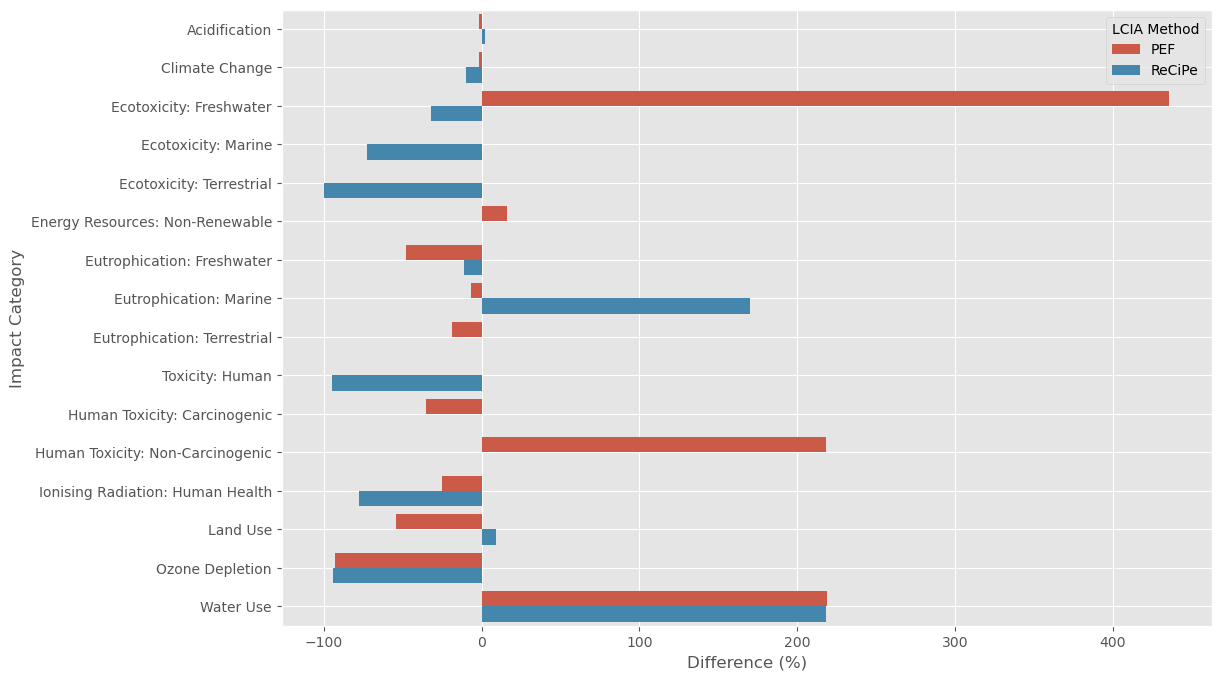

In [88]:
# Comparison of PEF and ReCiPe normalization references against this study's approach.
# Values are percentage differences: positive = this study overestimates,
# negative = this study underestimates relative to the published reference.
# Source: derived from df_NR_EF and df_NR_Recipe calculated in the cells above.
data = {
    "PEF": [-2, -2, 436, None, None, 16, -48, -7, -19, None, -35, 218, -25, -54, -93, 219],
    "ReCiPe": [2, -10, -32, -73, -100, None, -11, 170, None, -95, None, None, -78, 9, -94, 218],
    "Impact category": [
        "Acidification", "Climate Change", "Ecotoxicity: Freshwater", "Ecotoxicity: Marine", "Ecotoxicity: Terrestrial",
        "Energy Resources: Non-Renewable", "Eutrophication: Freshwater", "Eutrophication: Marine", "Eutrophication: Terrestrial",
        "Toxicity: Human", "Human Toxicity: Carcinogenic", "Human Toxicity: Non-Carcinogenic", "Ionising Radiation: Human Health",
        "Land Use", "Ozone Depletion", "Water Use"
    ]
}

df_LCIA_comp = pd.DataFrame(data)
df_LCIA_comp


# Melt the dataframe to have a long format suitable for seaborn
df_melted = df_LCIA_comp.melt(id_vars="Impact category", var_name="Type", value_name="Difference")

# Create the seaborn plot
plt.style.use('ggplot')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melted, x="Difference", y="Impact category", hue="Type")
plt.xlabel("Difference (%)")
plt.ylabel("Impact Category")
plt.legend(title="LCIA Method")
plt.grid(True)

# Save the plot as a PNG file
plt.savefig("LCIA_diff.png", bbox_inches='tight')

plt.show()

In [89]:
df[df['Substance name'] == 'Carbon dioxide, fossil'].sort_values(by='Total amount', ascending=False).to_excel('CO2.xlsx')

In [90]:
# Reaggregate the DataFrame grouping by CAS number, substance name, compartment, and unit.
# This is the final inventory used for comparison with the DTU reference inventory.
df_ei = df.groupby(
    ['CAS number', 'Substance name', 'Compartment', 'Unit'],
    as_index=False
).agg({'Total amount': 'sum'})
df_ei


,CAS number,Compartment,Unit,Substance name,Total amount
0,100-41-4,air,kilogram,"Benzene, ethyl-",3.836529e+07
1,100-41-4,water,kilogram,"Benzene, ethyl-",9.746503e+06
2,100-42-5,air,kilogram,Styrene,1.533826e+07
3,100-51-6,water,kilogram,Benzyl alcohol,5.747127e+05
4,100-52-7,air,kilogram,Benzaldehyde,1.162689e+07
...,...,...,...,...,...
1145,NOCAS,soil,kilogram,Mineral oil,1.642866e+10
1146,NOCAS,soil,megajoule,"Heat, waste",8.303447e+10
1147,NOCAS,water,kilo Becquerel,"Radioactive species, alpha emitters",3.393909e+10
1148,NOCAS,water,kilogram,"Hydrocarbons, unspecified",1.146655e+12


In [91]:
# Split the aggregated inventory into subsets for comparison:
#   - df_ei_cas:    flows with a valid CAS number (matchable to DTU inventory)
#   - df_ei_nocas:  flows without a CAS number (unspecified substances)
#   - df_ei_ionrad: ionizing radiation flows (unit = kBq), converted to Bq for comparison
df_ei_cas    = df_ei[df_ei['CAS number'] != 'NOCAS']
df_ei_nocas  = df_ei[df_ei['CAS number'] == 'NOCAS']
df_ei_ionrad = df_ei[df_ei['Unit'] == 'kilo Becquerel'].copy()
df_ei_ionrad['Total amount'] = 1000 * df_ei_ionrad['Total amount']  # kBq â†’ Bq
df_ei_ionrad['Unit'] = 'Bq'


## Comparison with EDGAR

The comparison benchmark is the public **EDGAR** global emission database (European Commission, Joint Research Centre). The reference year is **2018**, chosen to match the reference period of ecoinvent 3.8 (approximately 2017-2018).

EDGAR covers **atmospheric (air) emissions only**, so this comparison is restricted to the `air` compartment of the ecoinvent inventory.

Datasets used:
- Greenhouse gases (CO2, CH4, N2O): **EDGAR Community GHG database v8.0** (2023) - `v80_FT2022_GHG`. Methodology: Crippa et al. (2024), Earth Syst. Sci. Data 16, 2811-2830. https://doi.org/10.5194/essd-16-2811-2024
- CO and air pollutants (NOx, SO2, NH3, NMVOC, PM2.5): **EDGAR v8.1** (release August 2024) - `v81_FT2022_AP_new`. https://edgar.jrc.ec.europa.eu/index.php/dataset_ap81

The global totals below were computed directly from the official EDGAR workbooks: sheet `TOTALS BY COUNTRY`, header on row 10, unit **Gg**, summing the column `Y_2018` over all countries. The script `src/edgar_global_totals.py` in the repository reproduces them from the downloaded files. Sanity check: the computed fossil CO2 total (37.83 Gt) agrees with the published EDGAR value (37.9 Gt) to within 0.2 %.

Outputs: `comparison_ei_edgar.xlsx`, `ei_vs_EDGAR_ghg.png`, `ei_vs_EDGAR_ap.png`.

In [ ]:
# --- EDGAR reference totals (reference year 2018; values in kg/year) ---
# Greenhouse gases and F-gases: EDGAR Community GHG database v8.0 (2023).
# CO and air pollutants:        EDGAR v8.1 (release August 2024).
# Both from https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/EDGAR/datasets/
#   GHG -> v80_FT2022_GHG   |   air pollutants -> v81_FT2022_AP_new
#
# Totals were summed from the official "TOTALS BY COUNTRY" sheets (unit Gg,
# column Y_2018) with edgar_global_total() below; see src/edgar_global_totals.py.
# Reference year 2018 matches the ecoinvent 3.8 reference period (~2017-2018).
# Sanity check: fossil CO2 = 37.83 Gt vs published EDGAR value of 37.9 Gt (0.2 % off).
#
# NOTE on particulates: EDGAR PM10 INCLUDES the PM2.5 fraction, so the ecoinvent
# counterpart is the sum of "Particulates, < 2.5 um" and
# "Particulates, > 2.5 um, and < 10um". The flow "Particulates, > 10 um" is
# coarser than PM10 and is deliberately excluded.
GG_TO_KG = 1e6  # EDGAR reports in Gg; 1 Gg = 1e6 kg

EDGAR_TOTALS = [
    # --- Greenhouse gases (EDGAR v8.0, 2018) ---
    {"Label": "CO2 (fossil)", "Classification": "GHG",            "World total": 3.783188e13},  # 37.83 Gt
    {"Label": "CH4",          "Classification": "GHG",            "World total": 3.767290e11},  # 376.7 Mt
    {"Label": "N2O",          "Classification": "GHG",            "World total": 9.253000e09},  # 9.25 Mt
    {"Label": "CO",           "Classification": "GHG",            "World total": 4.419100e11},  # 441.9 Mt
    # --- F-gases (EDGAR v8.0, 2018). ecoinvent coverage falls into three tiers:
    #     good (CF4, C2F6 - primary aluminium), partial (HFC-134a/152a, SF6, HFC-23),
    #     and absent (HFC-125, HFC-143a, NF3 - refrigerant blends, semiconductor etching).
    {"Label": "HFC-134a",     "Classification": "F-gas",          "World total": 2.525125e08},  # 252.5 kt
    {"Label": "HFC-125",      "Classification": "F-gas",          "World total": 7.151770e07},  # 71.5 kt
    {"Label": "HFC-152a",     "Classification": "F-gas",          "World total": 5.261750e07},  # 52.6 kt
    {"Label": "HFC-143a",     "Classification": "F-gas",          "World total": 3.134060e07},  # 31.3 kt
    {"Label": "HFC-23",       "Classification": "F-gas",          "World total": 9.796900e06},  # 9.80 kt
    {"Label": "SF6",          "Classification": "F-gas",          "World total": 8.543300e06},  # 8.54 kt
    {"Label": "CF4",          "Classification": "F-gas",          "World total": 5.375000e06},  # 5.38 kt
    {"Label": "C2F6",         "Classification": "F-gas",          "World total": 7.918300e05},  # 0.79 kt
    {"Label": "NF3",          "Classification": "F-gas",          "World total": 1.422000e05},  # 0.14 kt
    # --- Air pollutants (EDGAR v8.1, 2018) ---
    {"Label": "NOx",          "Classification": "Air pollutants", "World total": 1.097270e11},  # 109.7 Mt
    {"Label": "SO2",          "Classification": "Air pollutants", "World total": 9.078600e10},  # 90.8 Mt
    {"Label": "NH3",          "Classification": "Air pollutants", "World total": 5.439100e10},  # 54.4 Mt
    {"Label": "NMVOC",        "Classification": "Air pollutants", "World total": 1.333740e11},  # 133.4 Mt
    {"Label": "PM2.5",        "Classification": "Air pollutants", "World total": 3.673200e10},  # 36.7 Mt
    {"Label": "PM10",         "Classification": "Air pollutants", "World total": 5.680764e10},  # 56.8 Mt
]
df_edgar = pd.DataFrame(EDGAR_TOTALS)


def edgar_global_total(path, year_col="Y_2018", sheet="TOTALS BY COUNTRY",
                       skiprows=9, substance=None):
    """Global annual total (kg/year) from an EDGAR workbook.

    The "TOTALS BY COUNTRY" sheet carries its header on row 10 (hence skiprows=9),
    one row per country, and one column per year ("Y_1970" ... "Y_2022"). Values
    are in Gg and are converted to kg here.

    The single-substance files (CO2, CH4, N2O, and each air pollutant) need no
    filter; the F-gas workbook holds 25 species, so pass ``substance`` there:

        edgar_global_total("IEA_EDGAR_CO2_1970_2022.xlsx")             # 3.783e13
        edgar_global_total("EDGAR_F-gases_1990_2022.xlsx", substance="SF6")
    """
    raw = pd.read_excel(path, sheet_name=sheet, skiprows=skiprows)
    if substance is not None:
        raw = raw[raw["Substance"] == substance]
    return pd.to_numeric(raw[year_col], errors="coerce").sum() * GG_TO_KG


df_edgar

In [ ]:
# Map ecoinvent air-emission flow names to the EDGAR benchmark labels.
# Several ecoinvent flows (e.g. fossil/non-fossil methane) map to one EDGAR gas.
# Verify these names against your ecoinvent version; unmatched flows are ignored.
SUBSTANCE_MAP = {
    "Carbon dioxide, fossil":                                             "CO2 (fossil)",
    "Methane, fossil":                                                    "CH4",
    "Methane, non-fossil":                                                "CH4",
    "Dinitrogen monoxide":                                                "N2O",
    "Carbon monoxide, fossil":                                            "CO",
    "Carbon monoxide, non-fossil":                                        "CO",
    "Sulfur hexafluoride":                                                "SF6",
    "Nitrogen trifluoride":                                               "NF3",
    "Ethane, 1,1,1,2-tetrafluoro-, HFC-134a":                            "HFC-134a",
    "Ethane, pentafluoro-, HFC-125":                                     "HFC-125",
    "Ethane, 1,1,1-trifluoro-, HFC-143a":                               "HFC-143a",
    "Nitrogen oxides":                                                   "NOx",
    "Sulfur dioxide":                                                    "SO2",
    "Ammonia":                                                           "NH3",
    "NMVOC, non-methane volatile organic compounds, unspecified origin": "NMVOC",
    "Particulates, < 2.5 um":                                            "PM2.5",
}

# Aggregate ecoinvent AIR emissions to the benchmark labels.
df_ei_air = df_ei[df_ei["Compartment"] == "air"].copy()
df_ei_air["Label"] = df_ei_air["Substance name"].map(SUBSTANCE_MAP)
df_ei_air = (
    df_ei_air.dropna(subset=["Label"])
    .groupby("Label", as_index=False)["Total amount"].sum()
)

# Merge ecoinvent vs EDGAR on the benchmark label (right join keeps all EDGAR rows).
df_ei_edgar = pd.merge(df_ei_air, df_edgar, on="Label", how="right")

# Diagnostics: warn about benchmark labels that did not match an ecoinvent flow.
missing = df_ei_edgar.loc[df_ei_edgar["Total amount"].isna(), "Label"].tolist()
if missing:
    print("No ecoinvent match for:", missing, "- check SUBSTANCE_MAP names")
df_ei_edgar

In [ ]:
# Relative difference of ecoinvent vs EDGAR (positive = ecoinvent overestimates).
df_ei_edgar["Relative difference [%]"] = (
    100 * (df_ei_edgar["Total amount"] - df_ei_edgar["World total"]) / df_ei_edgar["World total"]
)
df_ei_edgar = df_ei_edgar.sort_values("Relative difference [%]").reset_index(drop=True)
df_ei_edgar.to_excel("comparison_ei_edgar.xlsx", index=False)
df_ei_edgar

In [ ]:
# --- Figure 2: GHG inventory comparison (ecoinvent vs EDGAR, log-log) ---
plt.style.use("ggplot")

ghg = (
    df_ei_edgar[df_ei_edgar["Classification"] == "GHG"]
    .dropna(subset=["Total amount", "World total"])
    .reset_index(drop=True)
)

x_log = np.log10(ghg["Total amount"].to_numpy())
y_log = np.log10(ghg["World total"].to_numpy())
diagonal = [-7.5, 15]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.plot(x_log, y_log, "o")
ax.plot(diagonal, diagonal, "--", label="y=x")

# Per-point label offsets (dx, dy) in log10 units.
label_offsets = {
    "CO2 (fossil)": (0.3, -0.3), "CO": (0.3, -0.3), "CH4": (-1.6, 0.0),
    "N2O": (0.4, -0.3), "SF6": (0.2, 0.2), "NF3": (0.2, 0.2),
    "HFC-125": (0.2, 0.2), "HFC-143a": (0.0, 0.2), "HFC-134a": (0.3, -0.3),
}
for i, row in ghg.iterrows():
    dx, dy = label_offsets.get(row["Label"], (0.2, 0.2))
    ax.text(x_log[i] + dx, y_log[i] + dy, row["Label"])

ax.set_xlim(diagonal)
ax.set_ylim(diagonal)
ax.set_xlabel("log(ecoinvent)")
ax.set_ylabel("log(EDGAR)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("ei_vs_EDGAR_ghg.png", dpi=300)
plt.show()

In [ ]:
# --- Figure 3: Air pollutant inventory comparison (ecoinvent vs EDGAR, linear) ---
plt.style.use("ggplot")

ap = (
    df_ei_edgar[df_ei_edgar["Classification"] == "Air pollutants"]
    .dropna(subset=["Total amount", "World total"])
    .reset_index(drop=True)
)

x = ap["Total amount"].to_numpy()
y = ap["World total"].to_numpy()
upper = float(np.nanmax([x.max(), y.max()])) * 1.1 if len(ap) else 2e11
diagonal = [0, upper]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.plot(x, y, "o")
ax.plot(diagonal, diagonal, "--", label="y=x")
for i, row in ap.iterrows():
    ax.text(x[i], y[i], row["Label"])

ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.set_xlabel("ecoinvent [kg]")
ax.set_ylabel("EDGAR [kg]")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("ei_vs_EDGAR_ap.png", dpi=300)
plt.show()

# Building the Uncertainty Inventory

This section creates a second Brightway2 activity (`norm_unc`) that links to the **direct-linked** ecoinvent database (`ei38direct`) as technosphere exchanges weighted by production volumes. This construct enables Brightway2 to propagate parameter-level uncertainty distributions (lognormal by default in ecoinvent) through the full database during Monte Carlo simulation.

Steps:
1. Register or load the direct-linked database (`ei38direct`) â€” technosphere links are stripped so that uncertainty propagates only through biosphere exchanges
2. Apply the same metal flow and lognormal distribution corrections as the static inventory
3. Link all activities as technosphere inputs to `norm_unc` with demand = production volume Ã— reference product amount
4. Run static and Monte Carlo LCA to derive per-flow uncertainty (CV)


In [105]:
#del bd.databases['Normalization']
norm = bd.Database('Normalization')
norm.register()

In [106]:
global_inventory_uncertainty = norm.new_activity(code = 'norm_unc', name = 'Global inventory with uncertainty', unit = 'year')
global_inventory_uncertainty.save()

In [ ]:
import os  # To check file existence
from brightway2 import bw2data as bd, BW2Package  # Import required modules
from tqdm import tqdm
import time
from datetime import timedelta

# Check and delete the existing 'ecoinvent 3.8 cutoff direct' database if it exists
if 'ecoinvent 3.8 cutoff direct' in bd.databases:
    del bd.databases['ecoinvent 3.8 cutoff direct']
    print("'ecoinvent 3.8 cutoff direct' database deleted.")

# Path to the database file
database_file = "databases/ei38direct.8511d21d.bw2package"

if os.path.exists(database_file):
    # If the database file exists, import it
    BW2Package.import_file(database_file)
    print("Database imported successfully!")
else:
    print(f"Database file {database_file} not found. Proceeding with database modification...")

    # Handle database copying (run once)
    ei38cut.copy('ecoinvent 3.8 cutoff direct')  # Copy ei38cut to create the backup database

    # Process and clean up technosphere exchanges in ei38direct
    print("Cleaning technosphere exchanges...")
    from brightway2 import ei38direct  # Import ei38direct here to prevent issues if import was already done

    ei38direct_list = list(ei38direct)
    total_activities = len(ei38direct_list)

    start_time = time.time()

    # Progress bar loop for processing activities
    for idx, act in enumerate(tqdm(ei38direct_list, desc="Processing activities", unit="act")):
        for exc in act.technosphere():
            exc.delete()  # Delete each technosphere exchange
        act.save()  # Save the modified activity

    # Print time taken for the process
    end_time = time.time()
    print(f"Processing complete! Time taken: {timedelta(seconds=end_time - start_time)}")


In [109]:
ei38direct = bd.Database('ecoinvent 3.8 cutoff direct')

In [109]:
# Export the direct-linked database as a bw2package for re-use without re-processing.
# Set EI38_DIRECT_CACHE in the configuration cell at the top of this notebook.
bi.BW2Package.export_obj(
    ei38direct,
    filename=EI38_DIRECT_CACHE.stem,
    folder=str(EI38_DIRECT_CACHE.parent),
)


'C:\\Users\\nilst\\OneDrive - Universiteit Leiden\\Leiden\\LCA\\BW25\\Normalization\\databases\\ei38direct.8511d21d.bw2package'

In [139]:
# --- Zero out negative metal flows in the direct-linked database (ei38direct) ---
# This mirrors the correction applied to df, but directly modifies the brightway2
# database used for uncertainty propagation (Monte Carlo LCA).
# Additionally, all lognormal (uncertainty type 3) distributions are converted to
# deterministic (type 0) to ensure numerical stability during Monte Carlo sampling.
for activity in ei38direct:
    act = bd.get_activity(activity)
    for exc in act.biosphere():
        if exc['flow'] in METAL_UPTAKE_FLOW_IDS and exc['amount'] < 0:
            exc['uncertainty type'] = 0
            exc['loc'] = 0
            exc.save()
        elif exc['uncertainty type'] == 3:
            exc['uncertainty type'] = 0
            exc.save()


In [140]:
code = [
    node['id'] for node in ei38direct
    if 'maize silage production' in node['name']
    and 'maize silage' in node['reference product']
    and node['location'] == 'ZA'
]

In [141]:
# Retrieve the node
node = bd.get_node(id=code[0])

# Modify 'uncertainty type' for all parameters
for param in node['parameters']:
    param['uncertainty type'] = 0  # Replace with the desired value

# Save the updated node back
node.save()

In [142]:
# Build the "Global inventory with uncertainty" activity in the Normalization database.
# Each activity in ei38direct is linked as a technosphere exchange with an amount
# equal to its annual production volume Ã— reference product amount.
# This construct allows brightway2 to propagate parameter uncertainties through
# the full database during Monte Carlo simulation.
df_no_duplicates = df.drop_duplicates(subset='Id')

ids                    = df_no_duplicates['Id'].tolist()
production_volumes     = df_no_duplicates['Production volume'].tolist()
reference_prod_amounts = df_no_duplicates['Reference product amount'].tolist()

# Annual demand = production volume Ã— reference product amount
# (reference product amount != 1 for waste treatment datasets)
amounts = [pv * rpa for pv, rpa in zip(production_volumes, reference_prod_amounts)]
units   = [ei38direct.get(aid)['unit'] for aid in ids]
names   = [ei38direct.get(aid)['name'] for aid in ids]

for aid, amount, unit, name in zip(ids, amounts, units, names):
    global_inventory_uncertainty.new_exchange(
        input=ei38direct.get(aid),
        amount=amount,
        unit=unit,
        type='technosphere',
        name=name,
    ).save()
global_inventory_uncertainty.save()


In [ ]:
# Calculate normalization references for all IMPACTWorld+ categories
# using the uncertainty inventory (norm_unc) only.
NF_ImpactWorld = [getLCAresults(['norm_unc'], m) for m in ImpactWorld]
methods_names  = list(ImpactWorld)
units          = [bd.methods[m]['unit'] for m in ImpactWorld]

df_NR_ImpactWorld_unc = pd.DataFrame(NF_ImpactWorld, index=[methods_names, units])
df_NR_ImpactWorld_unc.to_excel('NR_ImpactWorld_uncertainty_inventory.xlsx')
df_NR_ImpactWorld_unc


In [ ]:
# Run a static (deterministic) LCA on the uncertainty inventory as a baseline reference
norm_unc = norm.get('norm_unc')

static = bc.LCA({norm_unc: 1}, ImpactWorld[0])
static.lci()
static.lcia()


In [ ]:
# Initialise the Monte Carlo LCA object with uncertainty distributions enabled
# (use_distributions=True activates parameter sampling from the stored uncertainty data)
mc = bc.LCA({norm_unc: 1}, ImpactWorld[0], use_distributions=True)
mc.lci()
mc.lcia()


In [ ]:
# Run 1000 Monte Carlo iterations to sample the uncertainty in the total LCIA score.
# A fixed random seed ensures reproducibility.
np.random.seed(42)
stochastic = [mc.score for _ in zip(range(1000), mc)]


In [ ]:
static.score, np.mean(stochastic), np.median(stochastic)

(52847564027529.17, 54693179931907.555, 54592443024770.3)

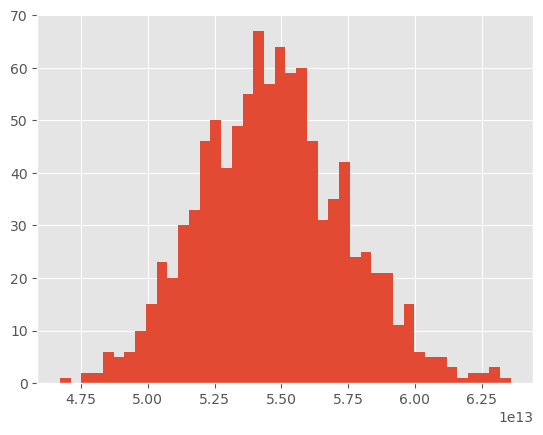

In [ ]:
plt.hist(stochastic, 42);

In [ ]:
# Run 1000 Monte Carlo iterations storing the full inventory vector (per-flow totals)
# rather than the aggregated LCIA score. This enables flow-level uncertainty analysis
# and coefficient-of-variation (CV) calculation per elementary flow.
np.random.seed(42)
stochastic = [np.sum(mc.inventory, axis=1) for _ in zip(range(1000), mc)]


In [ ]:
import pandas as pd
import bw2data as bd
import warnings


def create_inventory_dataframe(lca, cutoff=None):
    array = lca.inventory.sum(axis=1)
    
    if cutoff is not None and not (0 < cutoff < 1):
        warnings.warn(f"Ignoring invalid cutoff value {cutoff}")
        cutoff = None

    total = array.sum()
    include = lambda x: abs(x / total) >= cutoff if cutoff is not None else True

    if hasattr(lca, 'dicts'):
        mapping = lca.dicts.biosphere
    else:
        mapping = lca.biosphere_dict

    data = []

    for key, row in mapping.items():
        amount = array[row, 0]
        if include(amount):
            data.append((bd.get_activity(key), row, amount))

    data.sort(key=lambda x: abs(x[2]))

    return pd.DataFrame([{
            'row_index': row,
            'amount': amount,
            'name': flow.get('name'),
            'unit': flow.get('unit'),
            'categories': str(flow.get('categories'))
        } for flow, row, amount in data
    ])

In [ ]:
ca_df = create_inventory_dataframe(mc)
ca_df[ca_df['amount'] < 0]

,row_index,amount,name,unit,categories
1877,1093,-3.377999e+09,Cadmium,kilogram,"('soil', 'agricultural')"
1913,1352,-5.630471e+09,"Copper, ion",kilogram,"('water', 'surface water')"
1966,1491,-1.275963e+10,"Nickel, ion",kilogram,"('water', 'surface water')"
1973,1447,-1.516936e+10,Lead,kilogram,"('water', 'surface water')"
1999,1335,-2.726355e+10,"Chromium, ion",kilogram,"('water', 'surface water')"
2002,1124,-2.886786e+10,Lead,kilogram,"('soil', 'agricultural')"
2092,1811,-4.125556e+11,"Carbon dioxide, from soil or biomass stock",kilogram,"('air', 'non-urban air or from high stacks')"


In [ ]:
# ============================================================
# APPENDIX: Debugging cells for negative inventory flows
# ============================================================
# The cells below were used to trace the origin of residual negative flows
# in the Monte Carlo inventory matrix after the corrections above.
# They contain hardcoded matrix row indices and node IDs that are specific
# to the ecoinvent 3.8 cut-off database on the system where this was developed.
# They are preserved for transparency but are NOT part of the main workflow.
# Do not re-run these cells on a different system without updating the indices.
# ============================================================

import scipy.sparse as sp

# Inspect row 1113 of the inventory matrix (COO format) to find contributing columns
coo_matrix    = mc.inventory[1113, :].tocoo()
sorted_indices = np.argsort(coo_matrix.data)
sorted_values  = coo_matrix.data[sorted_indices]
sorted_columns = coo_matrix.col[sorted_indices]

for value, col in zip(sorted_values, sorted_columns):
    print(f"Value: {value}, Column: {col}")


In [ ]:
# Identify which activities contribute negative values for row 1104
inventory_matrix = mc.inventory.tocsc()
row_index        = 1104

col_indices = inventory_matrix[row_index, :].nonzero()[1]
values      = inventory_matrix[row_index, :].data
negative_col_indices = col_indices[values < 0]

for act in negative_col_indices:
    print(bd.get_node(id=mc.dicts.product.reversed[act]))


'beef cattle production on pasture and proteic supplement' (kilogram, BR, None)
'beef cattle production on pasture' (kilogram, BR, None)
'intensive beef cattle production on pasture' (kilogram, BR, None)
'fattening of heifers for beef cattle production, on pasture' (kilogram, RoW, None)
'intensive beef cattle production, fat steers only, on pasture' (kilogram, RoW, None)
'beef cattle production on pasture and feedlot' (kilogram, RoW, None)
'beef cattle production on pasture and feedlot' (kilogram, RoW, None)
'weaned calves production on pasture' (kilogram, BR, None)
'fattening of calves for beef cattle production, on pasture' (kilogram, BR, None)
'beef cattle production on pasture and proteic supplement' (kilogram, RoW, None)
'beef cattle production on pasture' (kilogram, ZA, None)
'intensive beef cattle production on pasture' (kilogram, RoW, None)
'fattening of calves for beef cattle production, on pasture' (kilogram, RoW, None)
'intensive beef cattle production, fat steers only, on p

In [ ]:
# Print the negative column indices identified above
negative_col_indices


array([ 2008,  2558,  3937,  4918,  5041,  5558,  6560,  8448, 10037,
       11347, 15331, 16457, 17391, 17928, 18049, 18226, 19297])

In [ ]:
# Inspect the activity at matrix column 5050 (system-specific node ID)
bd.get_node(id=mc.dicts.product.reversed[5050])


'market for window frame, wood-metal, U=1.6 W/m2K' (square meter, GLO, None)

In [ ]:
# Print all negative exchanges for the activity at matrix column 5050
for exc in bd.get_node(id=mc.dicts.product.reversed[5050]).exchanges():
    if exc['amount'] < 0:
        print(exc._data)
        print(exc['name'])
        print(exc['amount'])
        print(exc['loc'])
        print(exc['uncertainty type'])


In [ ]:
# Inspect raw data for activity at matrix column 9665
bd.get_node(id=mc.dicts.product.reversed[9665])._data


{'comment': '1 kg of this process is needed to produce 1 kg of final product. The data is an estimation based on the average consumption of factories separated into process specific (included here) and ancillary processes (included in metal working factory operation).\n[This dataset was already contained in the ecoinvent database version 2. It was not individually updated during the transfer to ecoinvent version 3. Life Cycle Impact Assessment results may still have changed, as they are affected by changes in the supply chain, i.e. in other datasets. This dataset was generated following the ecoinvent quality guidelines for version 2. It may have been subject to central changes described in the ecoinvent version 3 change report (http://www.ecoinvent.org/database/ecoinvent-version-3/reports-of-changes/), and the results of the central updates were reviewed extensively. The changes added e.g. consistent water flows and other information throughout the database. The documentation of this d

In [ ]:
# Fix: set uncertainty type to deterministic (0) for activity at matrix column 18166
node = bd.get_node(id=mc.dicts.product.reversed[18166])
for param in node['parameters']:
    param['uncertainty type'] = 0
node.save()


In [ ]:
# Verify fix: check remaining negative exchanges for activity at matrix column 2333
for exc in bd.get_node(id=mc.dicts.product.reversed[2333]).exchanges():
    if exc['amount'] < 0:
        print(exc._data)
        print(exc['uncertainty type'])


In [ ]:
# Extract flow metadata (name, code, CAS, category, unit, type) from the
# biosphere dictionary of the Monte Carlo LCA object.
# These lists are used to annotate the uncertainty results DataFrame.
name_lst, code_lst, cas_lst, cat_lst, unit_lst, type_lst = [], [], [], [], [], []

for key in mc.biosphere_dict.keys():
    name_lst.append(bd.get_activity(key).pop('name'))
    code_lst.append(bd.get_activity(key).pop('code'))
    cas_lst.append(bd.get_activity(key).pop('CAS number'))
    cat_lst.append(bd.get_activity(key).pop('categories'))
    unit_lst.append(bd.get_activity(key).pop('unit'))
    type_lst.append(bd.get_activity(key).pop('type'))


In [ ]:
df_flows = pd.read_excel('ecoinventEFv3.7-ILCD-EFv3.0.xlsx')
df_flows.head()

,SourceListName,SourceFlowName,SourceFlowUUID,SourceFlowContext,SourceUnit,MatchCondition,ConversionFactor,MapType,TargetListName,TargetFlowName,...,Flow Condition (S),Flow Condition (T),Flow Conf (S),Flow Conf (T),Context Condition (S),Context Condition (T),Context Conf (S),Context Conf (T),Conversion Conf (S),Conversion Conf (T)
0,Ecoinvent_3.7,"1,3-dioxolan-2-one",5b7d620e-2238-5ec9-888a-6999218b6974,water/unspecified,kg,NaN,NaN,CAS,EFv.3.0,"1,3-dioxolan-2-one",...,NaN,NaN,NaN,NaN,NaN,'=,A,A,NaN,NaN
1,Ecoinvent_3.7,"1,4-butanediol",d21da01e-f96f-4db5-9746-7b70db8a1f2c,"air/low population density, long-term",kg,NaN,NaN,NO_FLOW_MATCH_MANUAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ecoinvent_3.7,"1,4-butanediol",90653a29-2f53-4b1b-88bd-9ae2fe64a8d6,air/lower stratosphere + upper troposphere,kg,NaN,NaN,NO_FLOW_MATCH_MANUAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ecoinvent_3.7,"1,4-butanediol",83bafcf1-2f2e-4a32-89a0-f1f16ca10626,air/non-urban air or from high stacks,kg,NaN,NaN,NO_FLOW_MATCH_MANUAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ecoinvent_3.7,"1,4-butanediol",09db39be-d9a6-4fc3-8d25-1f80b23e9131,air/unspecified,kg,NaN,NaN,NO_FLOW_MATCH_MANUAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Build a UUID â†’ UUID mapping between ecoinvent 3.7 (ILCD) and EF v3.0 flow IDs.
# This crosswalk is required to align the Monte Carlo inventory results with the
# EF v3.0 characterization factors used for the final normalization reference calculation.
flow_match_dict = df_flows.set_index('SourceFlowUUID')['TargetFlowUUID'].to_dict()


In [ ]:
# Assemble the per-flow uncertainty results into a structured DataFrame.
# Each row is an elementary flow; columns include metadata and statistics
# (median, mean, std, CV, min, max) computed across the 1000 MC iterations.
# The CV (coefficient of variation = std / median) is the key uncertainty indicator.
df_unc = pd.DataFrame(np.concatenate(stochastic, axis=1).T)
df_unc = df_unc.transpose()

# Prepend metadata columns
df_unc.insert(0, 'type',        type_lst)
df_unc.insert(0, 'unit',        unit_lst)
df_unc.insert(0, 'category',    cat_lst)
df_unc.insert(0, 'cas',         cas_lst)
df_unc.insert(0, 'code',        code_lst)
df_unc.insert(1, 'code_target', df_unc['code'].map(flow_match_dict))
df_unc.insert(0, 'name',        name_lst)

# Compute summary statistics across MC runs (columns 0 onwards are run results)
df_unc.insert(6,  'median', df_unc.loc[:, 0:].median(axis=1))
df_unc.insert(7,  'mean',   df_unc.loc[:, 0:].mean(axis=1))
df_unc.insert(8,  'std',    df_unc.loc[:, 0:].std(axis=1))
df_unc.insert(9,  'cv',     df_unc['std'] / df_unc['median'])
df_unc.insert(10, 'min',    df_unc.loc[:, 0:].min(axis=1))
df_unc.insert(11, 'max',    df_unc.loc[:, 0:].max(axis=1))

# Split the tuple-valued 'category' column into separate compartment/sub-compartment columns
df_unc[['category1', 'category2']] = df_unc['category'].apply(lambda x: pd.Series(x))
df_unc = df_unc.drop('category', axis=1)
df_unc.insert(3, 'category',     df_unc['category1'])
df_unc.insert(4, 'sub-category', df_unc['category2'])
df_unc = df_unc.drop(['category1', 'category2'], axis=1)

df_unc.head()


,name,code,code_target,category,sub-category,cas,unit,median,mean,std,...,990,991,992,993,994,995,996,997,998,999
0,"1,4-Butanediol",38a622c6-f086-4763-a952-7c6b3b1c42ba,NaN,air,urban air close to ground,000110-63-4,kilogram,2.014987e+05,2.257391e+05,9.895299e+04,...,1.019119e+05,2.805325e+05,1.427565e+05,2.453128e+05,3.867573e+05,1.278480e+05,2.772024e+05,1.235339e+05,1.862928e+05,3.279633e+05
1,1-Pentanol,541a823c-0aad-4dc4-9123-d4af4647d942,9758dad7-53a4-4b38-9404-b6db9cb28c8b,air,urban air close to ground,000071-41-0,kilogram,1.052090e+04,1.127351e+04,3.679727e+03,...,7.523185e+03,9.991149e+03,1.296143e+04,9.770479e+03,8.523674e+03,7.246274e+03,1.044691e+04,1.240848e+04,1.045552e+04,1.502113e+04
2,1-Pentene,8cbaa905-41b0-4327-8403-bf1c8eb25429,fe0acd60-3ddc-11dd-9fe4-0050c2490048,air,urban air close to ground,000109-67-1,kilogram,5.491247e+05,5.513577e+05,4.099695e+04,...,5.130708e+05,5.210239e+05,5.363519e+05,5.382545e+05,4.834832e+05,5.833586e+05,5.465622e+05,5.177208e+05,6.438761e+05,4.818781e+05
3,"2,4-D",f681eb3c-854a-4f78-bcfe-76dfbcf9df3c,08a91e70-3ddc-11dd-918a-0050c2490048,soil,agricultural,000094-75-7,kilogram,6.269680e+07,6.308971e+07,4.820996e+06,...,5.638418e+07,6.632581e+07,7.802515e+07,6.273320e+07,5.737742e+07,6.666933e+07,5.858334e+07,6.067382e+07,6.292499e+07,6.445729e+07
4,2-Aminopropanol,a0fec60d-3f74-48bf-a2d2-58c30fc13e53,280b0876-9c74-47a2-b743-69750b1c7150,air,urban air close to ground,002749-11-3,kilogram,3.336092e+04,3.533173e+04,1.050909e+04,...,4.008871e+04,2.895535e+04,3.476828e+04,4.243190e+04,4.120364e+04,3.353607e+04,3.971148e+04,2.780653e+04,1.797751e+04,3.151294e+04


In [ ]:
# Assuming df is your DataFrame
excel_filename = 'global_inventory_uncertainty.xlsx'
df_unc.to_excel(excel_filename, index=False)

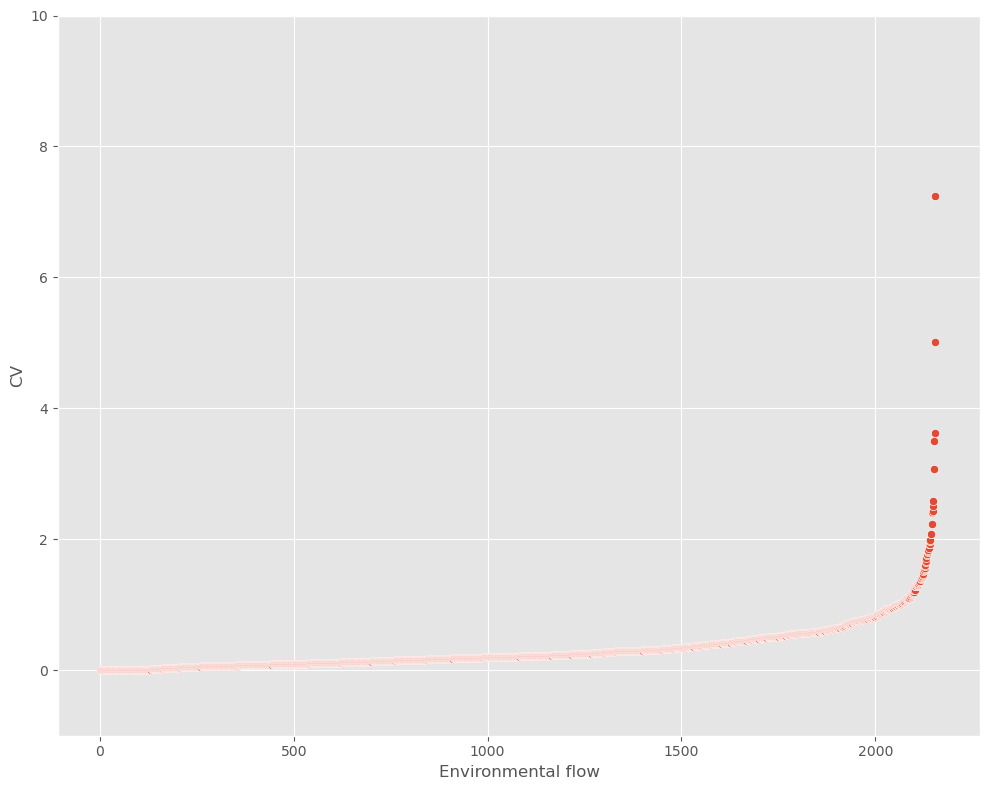

In [ ]:
# Sort by the differences
df_unc_sorted = df_unc.sort_values(by='cv').reset_index()

# Plot
plt.figure(figsize=(10, 8))
plt.style.use('ggplot')
dotplot = sns.scatterplot(data=df_unc_sorted, x=df_unc_sorted.index, y='cv')

# Add titles and labels
#plt.title('Discrepancy between Total Amount and World Total')
plt.xlabel('Environmental flow')
plt.ylabel('CV')
plt.grid(True)
plt.ylim(-1,10)

# Show plot
plt.tight_layout()
plt.savefig("cv_dot_plot.png", dpi=300)
plt.show()

# Summary and Outputs

This notebook produces the following files used in the manuscript:

| File | Description |
|------|-------------|
| `ei_complete.pkl` | Cached database-wide biosphere inventory |
| `Normalization_complete_new.xlsx` | Complete normalization inventory (all flows) |
| `Normalization_Inventory_Toxics.xlsx` | Toxicity subset (non-resource, kg flows only) |
| `Global_inventory_ionizing_radiation_ecoinvent_3.8_complete.xlsx` | Ionizing radiation inventory with sub-compartments |
| `NR_EF.xlsx` | Normalization references â€” EF v3.0 |
| `NR_Recipe.xlsx` | Normalization references â€” ReCiPe |
| `df_NR_ImpactWorld.xlsx` | Normalization references â€” IMPACTWorld+ |
| `global_inventory_uncertainty.xlsx` | Per-flow uncertainty statistics (CV, median, std) |
| `comparison_ei_edgar.xlsx` | Ecoinvent vs EDGAR inventory comparison |
| `CC_impact_sector_bar_chart.png` | Figure 5: GWI by ISIC sector |
| `ei_vs_EDGAR_ghg.png` | Figure 2: GHG inventory comparison |
| `ei_vs_EDGAR_ap.png` | Figure 3: Air pollutant inventory comparison |
| `LCIA_diff.png` | Figure 4: Normalization reference comparison (PEF vs ReCiPe) |
| `cv_hist_plot.png` | Figure 6: Coefficient of variation histogram |

> **Reproducibility note:** All outputs depend on the ecoinvent 3.8 cut-off database (commercial licence required). The production volume corrections, metal flow adjustments, and LCIA method packages are documented in the cells above and in the supporting information of the manuscript.


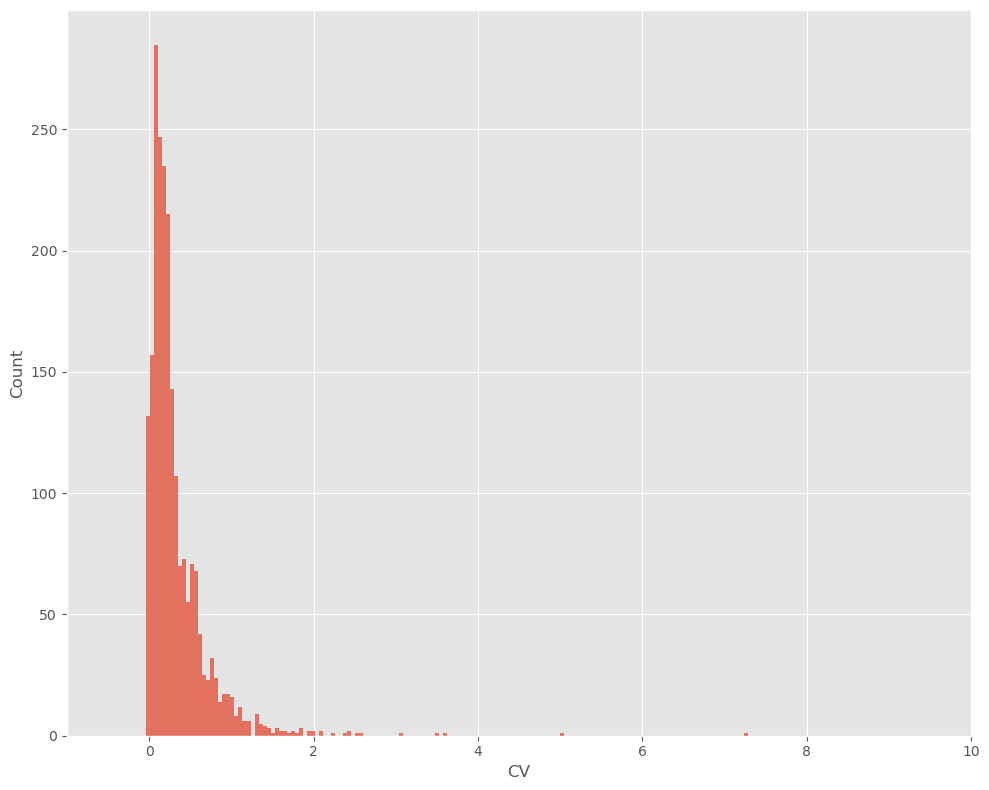

In [ ]:
# Sort the DataFrame by the 'cv' column in ascending order and reset the index
df_unc_sorted = df_unc.sort_values(by='cv').reset_index()

# Create a histogram plot to visualize the distribution of the 'cv' column
plt.figure(figsize=(10, 8))  # Set the figure size
plt.style.use('ggplot')  # Apply the 'ggplot' style for better aesthetics
dotplot = sns.histplot(data=df_unc_sorted, x='cv')  # Plot the histogram using seaborn

# Add labels and grid to the plot for better readability
plt.xlabel('CV')  # Label for the x-axis
plt.ylabel('Count')  # Label for the y-axis
plt.grid(True)  # Enable grid lines for better visualization
plt.xlim(-1, 10)  # Set the x-axis limits to focus on the desired range

# Save the plot as a high-resolution image and display it
plt.tight_layout()  # Adjust layout to prevent overlapping elements
plt.savefig("cv_hist_plot.png", dpi=300)  # Save the plot as a PNG file with 300 DPI
plt.show()  # Display the plot